# Teste do Módulo `features_extraction`

Este notebook testa todas as funcionalidades do módulo `features_extraction`, incluindo:
- Extração de features de camadas específicas
- Extração de features de todas as camadas
- Diferentes estratégias de pooling (cls, mean, max, token)
- Extração de metafeatures com PyMFE
- Gerenciamento de dispositivos
- Configurações customizadas


## 1. Setup e Imports


In [9]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
!pip show pymfe

Name: pymfe
Version: 0.4.4
Summary: Meta-feature Extractor
Home-page: https://github.com/ealcobaca/pymfe
Author: 
Author-email: 
License: MIT
Location: /Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages
Requires: gower, igraph, numpy, pandas, patsy, scikit-learn, scipy, statsmodels, texttable, tqdm
Required-by: 


In [4]:
import sys
import os
import logging
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# add parent directory so Python can find features_extraction/
sys.path.insert(0, os.path.abspath('..'))

# 1) import the package/module first
import features_extraction

# 2) then reload it
importlib.reload(features_extraction)

# 3) now import what you need from it (freshly)
from features_extraction import (
    FeaturesExtraction,
    ExtractionConfig,
    MetaFeatureConfig,
    DeviceManager,
)
from features_extraction.utils import setup_logging
from features_extraction.pooling import POOLING_STRATEGIES

# logging
setup_logging(level=logging.INFO)

# plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports realizados com sucesso!")


/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports realizados com sucesso!


## 2. Configuração Inicial


In [13]:
# Verificar dispositivo disponível
device_info = DeviceManager.get_device_info()
print("📱 Informações do Dispositivo:")
for key, value in device_info.items():
    print(f"  {key}: {value}")

device = DeviceManager.resolve("auto")
print(f"\n🎯 Dispositivo selecionado: {device}")


2026-02-05 10:40:27 [INFO] features_extraction.device: Auto-selected Apple MPS device


📱 Informações do Dispositivo:
  cuda_available: False
  cuda_device_count: 0
  mps_available: True

🎯 Dispositivo selecionado: mps


## 3.1 Fine-tuning do Modelo

Antes de extrair as metafeatures, vamos fazer o fine-tuning do modelo no dataset RTE para melhorar sua performance na tarefa específica.

In [14]:
# Imports adicionais para fine-tuning
from transformers import (
    Trainer, 
    TrainingArguments, 
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports para fine-tuning carregados!")

✅ Imports para fine-tuning carregados!


In [15]:
# Carregar dataset completo para fine-tuning
print("📥 Carregando datasets de treino e validação...")

train_dataset = load_dataset("glue", "rte", split="train")
val_dataset = load_dataset("glue", "rte", split="validation")

print(f"✅ Datasets carregados:")
print(f"   Treino: {len(train_dataset)} exemplos")
print(f"   Validação: {len(val_dataset)} exemplos")
print(f"   Classes: {train_dataset.features['label'].num_classes}")
print(f"   Exemplo: {train_dataset[0]}")

📥 Carregando datasets de treino e validação...
✅ Datasets carregados:
   Treino: 2490 exemplos
   Validação: 277 exemplos
   Classes: 2
   Exemplo: {'sentence1': 'No Weapons of Mass Destruction Found in Iraq Yet.', 'sentence2': 'Weapons of Mass Destruction Found in Iraq.', 'label': 1, 'idx': 0}
✅ Datasets carregados:
   Treino: 2490 exemplos
   Validação: 277 exemplos
   Classes: 2
   Exemplo: {'sentence1': 'No Weapons of Mass Destruction Found in Iraq Yet.', 'sentence2': 'Weapons of Mass Destruction Found in Iraq.', 'label': 1, 'idx': 0}


In [16]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import os

In [22]:
fine_tuned_path = "./roberta_rte_finetuned_best"
model_name = "roberta-base"

if os.path.exists(fine_tuned_path):
    tokenizer = RobertaTokenizer.from_pretrained(fine_tuned_path)
    model = RobertaForSequenceClassification.from_pretrained(fine_tuned_path)
    print("✅ Modelo fine-tunado carregado.")
else:
    tokenizer = RobertaTokenizer.from_pretrained(model_name)
    model = RobertaForSequenceClassification.from_pretrained(model_name)
    print("⚠️ Modelo base carregado; execute o fine-tuning para melhores resultados.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


⚠️ Modelo base carregado; execute o fine-tuning para melhores resultados.


In [23]:
# Função para calcular métricas
def compute_metrics(eval_pred):
    """Calcula accuracy, precision, recall e F1"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("✅ Função de métricas definida!")

✅ Função de métricas definida!


In [59]:
# Configurar argumentos de treinamento
print("⚙️ Configurando parâmetros de treinamento...")

training_args = TrainingArguments(
    output_dir="./results_rte_finetuned",
    num_train_epochs=30,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.06,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to="none",
    seed=42,
)

# Data collator para padding dinâmico
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("✅ Configuração concluída!")
print(f"   Épocas: {training_args.num_train_epochs}")
print(f"   Batch size (treino): {training_args.per_device_train_batch_size}")
print(f"   Batch size (validação): {training_args.per_device_eval_batch_size}")

⚙️ Configurando parâmetros de treinamento...
✅ Configuração concluída!
   Épocas: 30
   Batch size (treino): 16
   Batch size (validação): 32


In [60]:
# Função de tokenização para o dataset
def tokenize_function(examples):
    s1 = ["" if x is None else str(x) for x in examples["sentence1"]]
    s2 = ["" if x is None else str(x) for x in examples["sentence2"]]

    return tokenizer(
        s1,
        s2,
        truncation="only_first",   # sugestão p/ RTE
        max_length=128,
        padding="max_length",
    )

# Tokenizar datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# Preparar datasets para o Trainer
tokenized_train = tokenized_train.remove_columns(['sentence1', 'sentence2', 'idx'])
tokenized_val = tokenized_val.remove_columns(['sentence1', 'sentence2', 'idx'])
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

In [61]:
# Criar Trainer
print("🏋️ Criando Trainer...")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("✅ Trainer criado com sucesso!")
print(f"   Modelo: {model.__class__.__name__}")
print(f"   Dispositivo: {training_args.device}")

🏋️ Criando Trainer...
✅ Trainer criado com sucesso!
   Modelo: RobertaForSequenceClassification
   Dispositivo: mps


In [62]:
# Executar fine-tuning
print("🚀 Iniciando fine-tuning...")
print("=" * 80)

train_result = trainer.train()

print("=" * 80)
print("✅ Fine-tuning concluído!")
print(f"\n📊 Resultados do treinamento:")
print(f"   Loss final: {train_result.training_loss:.4f}")
print(f"   Tempo de treinamento: {train_result.metrics['train_runtime']:.2f}s")
print(f"   Samples/segundo: {train_result.metrics['train_samples_per_second']:.2f}")

🚀 Iniciando fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.139100,1.276940,0.671480,0.685185,0.564885,0.619247
2,0.163000,1.313701,0.678700,0.690909,0.580153,0.630705
3,0.361100,1.131712,0.653430,0.631579,0.641221,0.636364
4,0.149200,1.461355,0.693141,0.712963,0.587786,0.644351
5,0.174100,1.369452,0.657040,0.691489,0.496183,0.577778
6,0.127300,1.543041,0.671480,0.763158,0.442748,0.560386
7,0.097500,1.756620,0.649819,0.712500,0.435115,0.540284
8,0.125900,1.891999,0.664260,0.637681,0.671756,0.654275
9,0.045300,2.127138,0.660650,0.669725,0.557252,0.608333
10,0.076100,1.977076,0.646209,0.663366,0.511450,0.577586


✅ Fine-tuning concluído!

📊 Resultados do treinamento:
   Loss final: 0.0653
   Tempo de treinamento: 2226.54s
   Samples/segundo: 33.55


In [63]:
# Avaliar modelo no conjunto de validação
print("📊 Avaliando modelo fine-tunado...")

eval_results = trainer.evaluate()

print("✅ Avaliação concluída!")
print(f"\n📈 Métricas no conjunto de validação:")
print(f"   Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"   Precision: {eval_results['eval_precision']:.4f}")
print(f"   Recall: {eval_results['eval_recall']:.4f}")
print(f"   F1-Score: {eval_results['eval_f1']:.4f}")
print(f"   Loss: {eval_results['eval_loss']:.4f}")

📊 Avaliando modelo fine-tunado...


✅ Avaliação concluída!

📈 Métricas no conjunto de validação:
   Accuracy: 0.6534
   Precision: 0.6316
   Recall: 0.6412
   F1-Score: 0.6364
   Loss: 1.1317


In [64]:
# Salvar modelo fine-tunado
output_dir = "./roberta_rte_finetuned_best"
print(f"💾 Salvando modelo fine-tunado em {output_dir}...")

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print("✅ Modelo salvo com sucesso!")
print(f"   Diretório: {output_dir}")

💾 Salvando modelo fine-tunado em ./roberta_rte_finetuned_best...
✅ Modelo salvo com sucesso!
   Diretório: ./roberta_rte_finetuned_best


## Comparar com modelo HuggingFace: DeBERTa-v3-base fine-tunado

In [17]:
# Avaliar modelo DeBERTa-v3-base fine-tunado do HuggingFace
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch

print("Carregando modelo DeBERTa-v3-base fine-tunado...")
deberta_model_name = "RazyDave/deberta-v3-base-finetuned-rte"
deberta_model = AutoModelForSequenceClassification.from_pretrained(deberta_model_name)
deberta_tokenizer = AutoTokenizer.from_pretrained(deberta_model_name)

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
deberta_model.to(device)
deberta_model.eval()

# Tokenizar dados de validação
def tokenize_for_deberta(examples):
    s1 = ["" if x is None else str(x) for x in examples["sentence1"]]
    s2 = ["" if x is None else str(x) for x in examples["sentence2"]]
    return deberta_tokenizer(s1, s2, truncation="only_first", max_length=128, padding="max_length")

val_tokenized = val_dataset.map(tokenize_for_deberta, batched=True)
val_tokenized = val_tokenized.remove_columns(['sentence1', 'sentence2', 'idx'])
val_tokenized.set_format('torch')

# Avaliar
print("Avaliando DeBERTa no conjunto de validação...")
val_loader = torch.utils.data.DataLoader(val_tokenized, batch_size=32, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = deberta_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calcular métricas
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')

print(f"\n✅ Resultados de avaliação - DeBERTa-v3-base-finetuned-rte:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1:        {f1:.4f}")

print(f"\n📊 Comparação com RoBERTa fine-tunado:")
print(f"  RoBERTa - Accuracy: {eval_results['eval_accuracy']:.4f}, F1: {eval_results['eval_f1']:.4f}")
print(f"  DeBERTa - Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

Carregando modelo DeBERTa-v3-base fine-tunado...


Map: 100%|██████████| 277/277 [00:00<00:00, 6495.82 examples/s]



Avaliando DeBERTa no conjunto de validação...

✅ Resultados de avaliação - DeBERTa-v3-base-finetuned-rte:
  Accuracy:  0.8267
  Precision: 0.8074
  Recall:    0.8321
  F1:        0.8195

📊 Comparação com RoBERTa fine-tunado:

✅ Resultados de avaliação - DeBERTa-v3-base-finetuned-rte:
  Accuracy:  0.8267
  Precision: 0.8074
  Recall:    0.8321
  F1:        0.8195

📊 Comparação com RoBERTa fine-tunado:


NameError: name 'eval_results' is not defined

---

## 4. Testes com Modelo Fine-tunado

A partir daqui, todas as extrações de features e metafeatures serão feitas usando o **modelo fine-tunado** no dataset RTE.

In [ ]:

model = trainer.model

print("✅ Modelo atualizado para versão fine-tunada")
print(f"   Modelo: {model.__class__.__name__}")
print(f"   Parâmetros: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Modo: Fine-tuned no RTE dataset")

## 3. Carregar Modelo e Dataset


In [11]:
model = RobertaForSequenceClassification.from_pretrained("../pretrained_models/roberta_rte_finetuned_best")


In [10]:
# Carregar modelo e tokenizer pré-treinados
print("📥 Carregando modelo e tokenizer...")
model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaForSequenceClassification.from_pretrained(model_name)

print(f"✅ Modelo '{model_name}' carregado com sucesso!")
print(f"   Parâmetros: {sum(p.numel() for p in model.parameters()):,}")


📥 Carregando modelo e tokenizer...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Modelo 'roberta-base' carregado com sucesso!
   Parâmetros: 124,647,170


In [9]:
# Função de tokenização para o dataset RTE
def tokenize_rte(tokenizer, batch, max_length):
    """Tokeniza pares de sentenças para a tarefa RTE."""
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        padding="longest",
        truncation=True,
        max_length=max_length,
    )

print("✅ Função de tokenização definida")


✅ Função de tokenização definida


## 6. Teste 3: Extração de Todas as Camadas


In [97]:

full_dataset = load_dataset("glue", "rte", split="train")

config = ExtractionConfig(
    batch_size=8,
    max_length=128,
    device="auto",
    pooling="mean",
    return_numpy=True,
    output_path="../features_extraction/full_rte_allsplits_features.npz"  # Salvar features em arquivo
)

extractor = FeaturesExtraction(model, tokenizer)

features_by_layer, labels_all = extractor.extract_all_layers(
    dataset=full_dataset,
    tokenize_fn=tokenize_rte,
    config=config
)

print(f"\n✅ Features de todas as camadas extraídas e salvas em 'features_extraction/full_rte_allsplits_features.npz'!")
print(f"   Número de camadas: {len(features_by_layer)}")
print(f"   Labels shape: {labels_all.shape if labels_all is not None else None}")
print(f"\n📋 Camadas extraídas:")
for layer_name, features_layer in list(features_by_layer.items())[:5]:
    print(f"   {layer_name}: {features_layer.shape}")
print(f"   ...")
for layer_name, features_layer in list(features_by_layer.items())[-2:]:
    print(f"   {layer_name}: {features_layer.shape}")

    print(f"   {layer_name}: {features_layer.shape}")

2026-01-20 13:19:27 [INFO] features_extraction.core: Initialized FeaturesExtraction with model=RobertaForSequenceClassification, tokenizer=RobertaTokenizer
2026-01-20 13:19:27 [INFO] features_extraction.utils: Starting extract_all_layers
2026-01-20 13:19:27 [INFO] features_extraction.device: Auto-selected Apple MPS device
2026-01-20 13:19:27 [INFO] features_extraction.tokenizer: Tokenizing dataset: keeping {'labels', 'label'}, removing 3 columns
Tokenizing dataset:   0%|          | 0/2490 [00:00<?, ? examples/s]Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens ar


✅ Features de todas as camadas extraídas e salvas em 'features_extraction/full_rte_allsplits_features.npz'!
   Número de camadas: 13
   Labels shape: (2490,)

📋 Camadas extraídas:
   embeddings: (2490, 768)
   layer_0: (2490, 768)
   layer_1: (2490, 768)
   layer_2: (2490, 768)
   layer_3: (2490, 768)
   ...
   layer_10: (2490, 768)
   layer_10: (2490, 768)
   layer_11: (2490, 768)
   layer_11: (2490, 768)


In [1]:
# Load DeBERTa features from NPZ file
import numpy as np

npz_path = "../data/features/deberta_v3_base_finetuned_rte_allsplits_features.npz"
loaded_data = np.load(npz_path, allow_pickle=True)

print("Available arrays in the file:", loaded_data.files)

# Extract feature keys (all layers + embeddings)
feature_keys = [k for k in loaded_data.files if k.startswith("features_")]

# Load all features into features_by_layer dictionary
features_by_layer = {k: loaded_data[k] for k in feature_keys}

# Load labels
labels_all = loaded_data["labels"]

print(f"\n✅ DeBERTa features loaded successfully!")
print(f"   Number of layers: {len(features_by_layer)}")
print(f"   Labels shape: {labels_all.shape}")
print(f"\n📋 Layers loaded:")
for layer_name, features_layer in list(features_by_layer.items())[:5]:
    print(f"   {layer_name}: {features_layer.shape}")
if len(features_by_layer) > 5:
    print(f"   ...")
    for layer_name, features_layer in list(features_by_layer.items())[-2:]:
        print(f"   {layer_name}: {features_layer.shape}")

Available arrays in the file: ['features_embeddings', 'features_layer_0', 'features_layer_1', 'features_layer_2', 'features_layer_3', 'features_layer_4', 'features_layer_5', 'features_layer_6', 'features_layer_7', 'features_layer_8', 'features_layer_9', 'features_layer_10', 'features_layer_11', 'labels']

✅ DeBERTa features loaded successfully!
   Number of layers: 13
   Labels shape: (2490,)

📋 Layers loaded:
   features_embeddings: (2490, 768)
   features_layer_0: (2490, 768)
   features_layer_1: (2490, 768)
   features_layer_2: (2490, 768)
   features_layer_3: (2490, 768)
   ...
   features_layer_10: (2490, 768)
   features_layer_11: (2490, 768)

✅ DeBERTa features loaded successfully!
   Number of layers: 13
   Labels shape: (2490,)

📋 Layers loaded:
   features_embeddings: (2490, 768)
   features_layer_0: (2490, 768)
   features_layer_1: (2490, 768)
   features_layer_2: (2490, 768)
   features_layer_3: (2490, 768)
   ...
   features_layer_10: (2490, 768)
   features_layer_11: (249

#### Identificação se há layes com vetores/colunas nulos

In [2]:
def zero_rows_cols(X):
    # X: [N, D]
    row_zero = np.all(X == 0, axis=1)
    col_zero = np.all(X == 0, axis=0)
    return row_zero, col_zero

def report_zero_stats(features_by_layer, topk=5):
    for ln, X in features_by_layer.items():
        X = np.asarray(X)
        row_zero, col_zero = zero_rows_cols(X)
        print(f"\nLayer {ln}")
        print("  shape:", X.shape)
        print("  all-zero rows:", int(row_zero.sum()))
        print("  all-zero cols:", int(col_zero.sum()))

        # (opcional) mostrar índices de algumas linhas zero
        if row_zero.any():
            idx = np.where(row_zero)[0][:topk]
            print("  example zero-row idx:", idx)

        if col_zero.any():
            idx = np.where(col_zero)[0][:topk]
            print("  example zero-col idx:", idx)

        # NaN/Inf
        n_nan = np.isnan(X).sum()
        n_inf = np.isinf(X).sum()
        print("  NaN:", int(n_nan), "Inf:", int(n_inf))

# se você tiver features_by_layer
report_zero_stats(features_by_layer)



Layer features_embeddings
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer features_layer_0
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer features_layer_1
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer features_layer_2
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer features_layer_3
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer features_layer_4
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer features_layer_5
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer features_layer_6
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer features_layer_7
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer features_layer_8
  shape: (2490, 768)
  all-zero rows: 0
  all-zero cols: 0
  NaN: 0 Inf: 0

Layer 

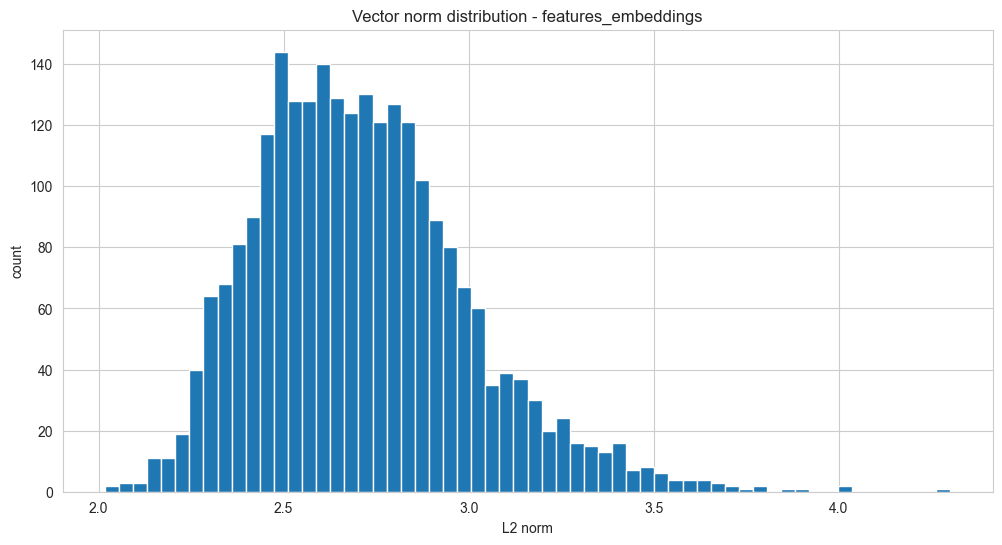

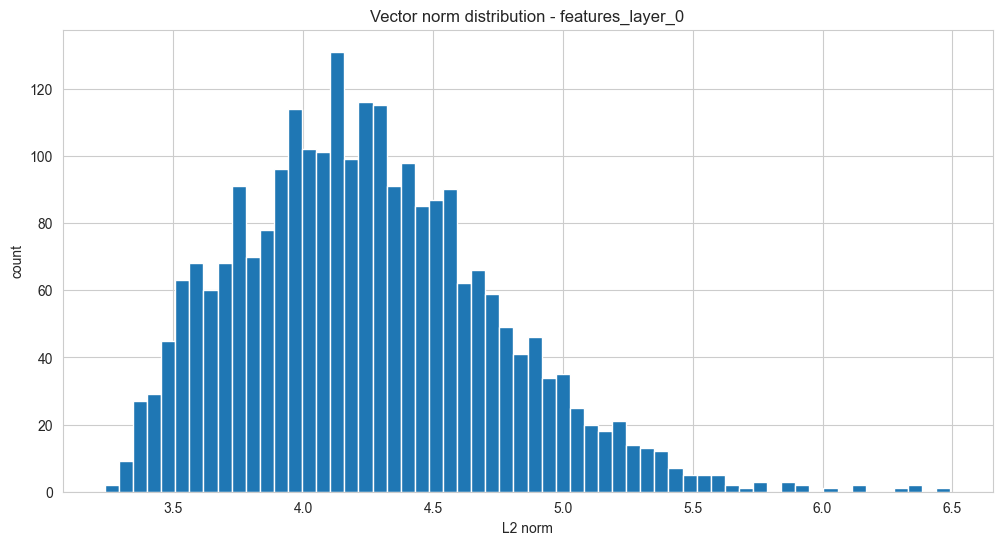

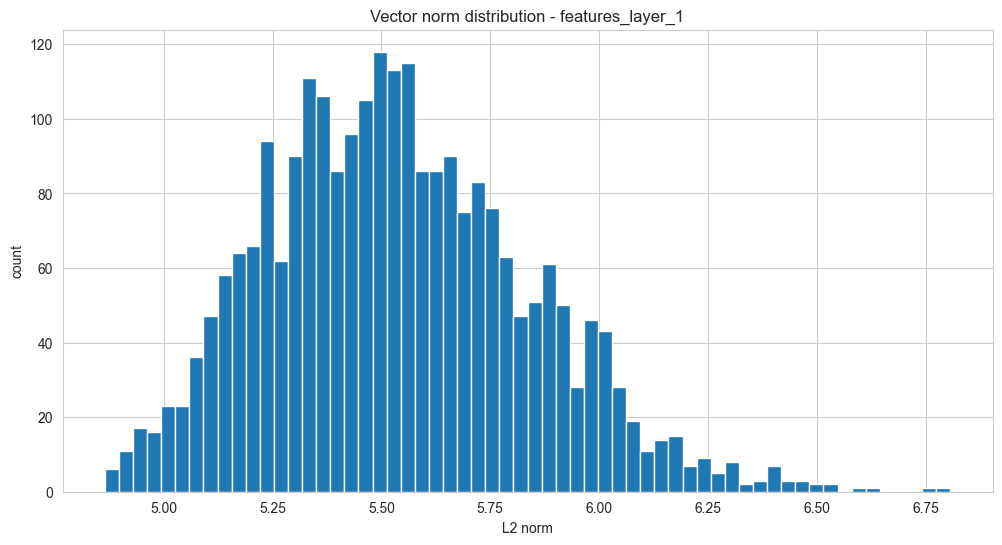

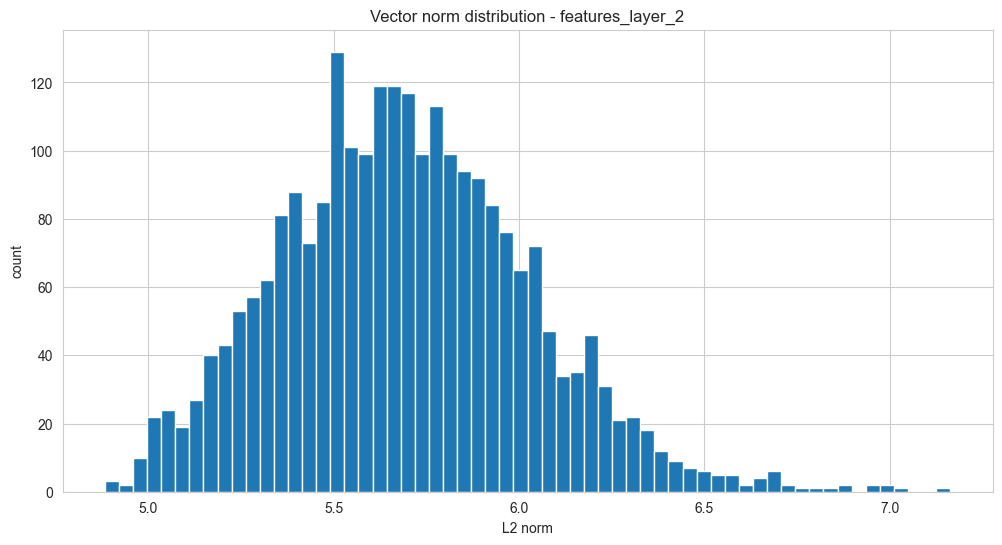

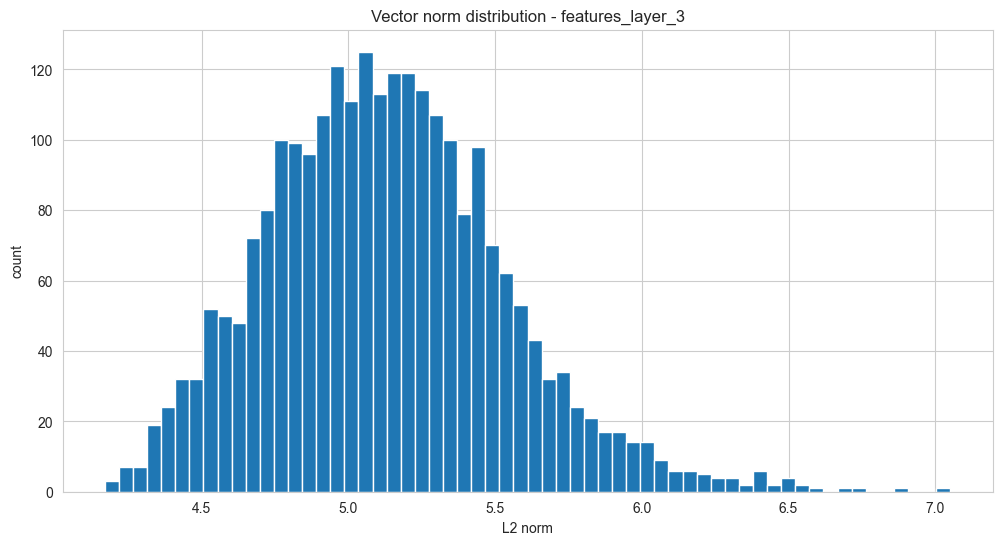

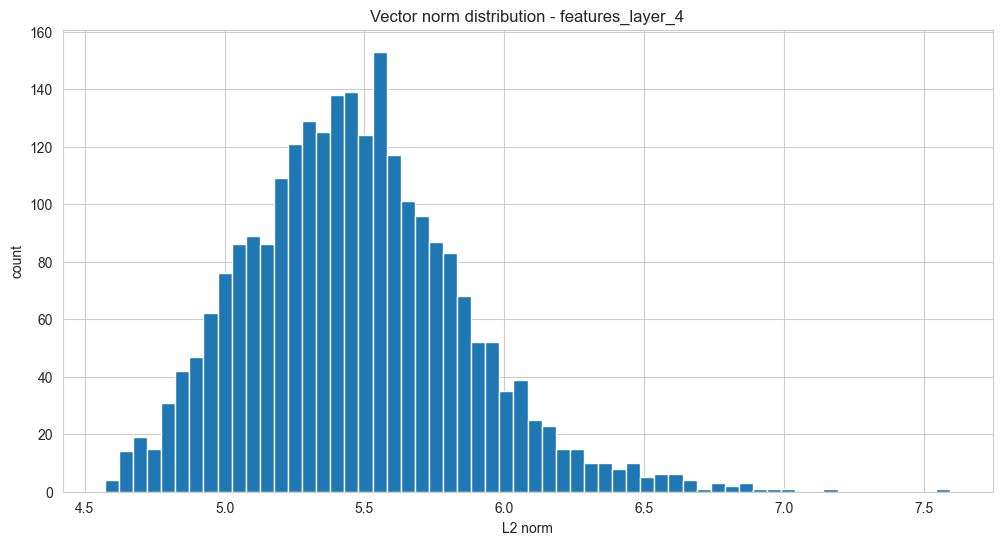

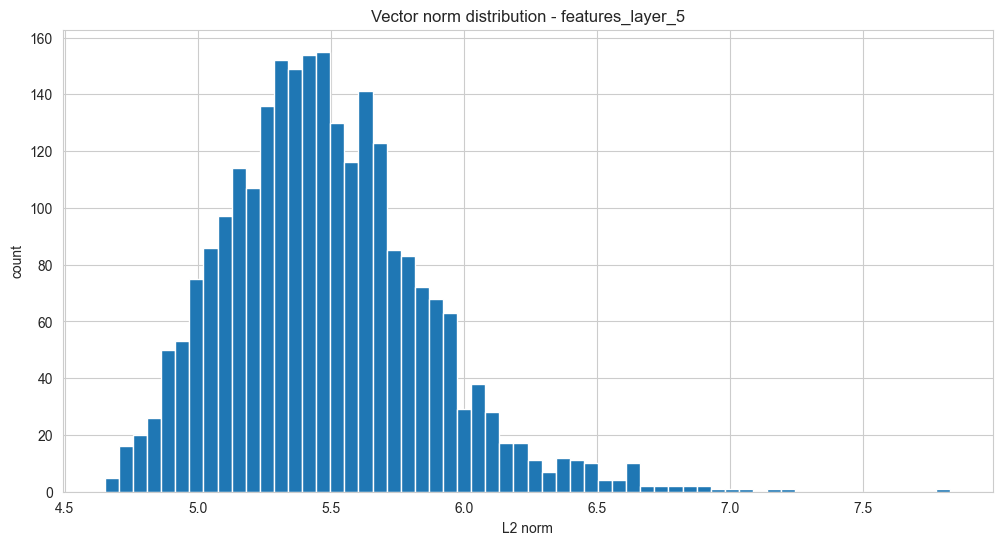

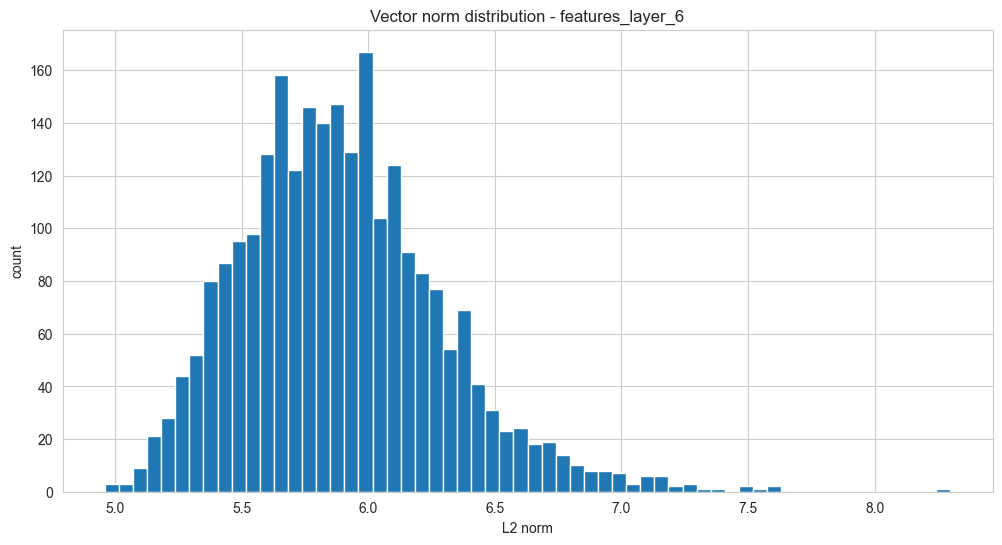

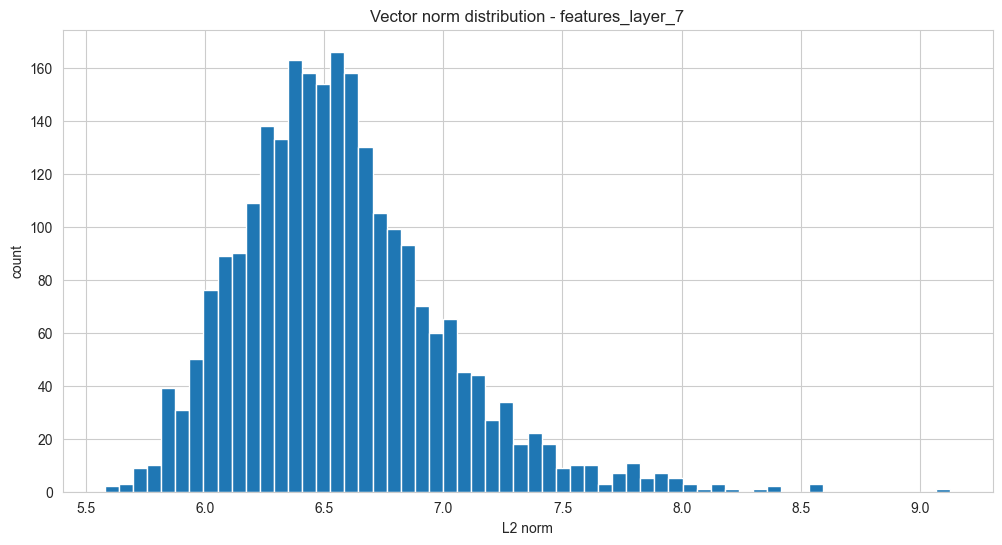

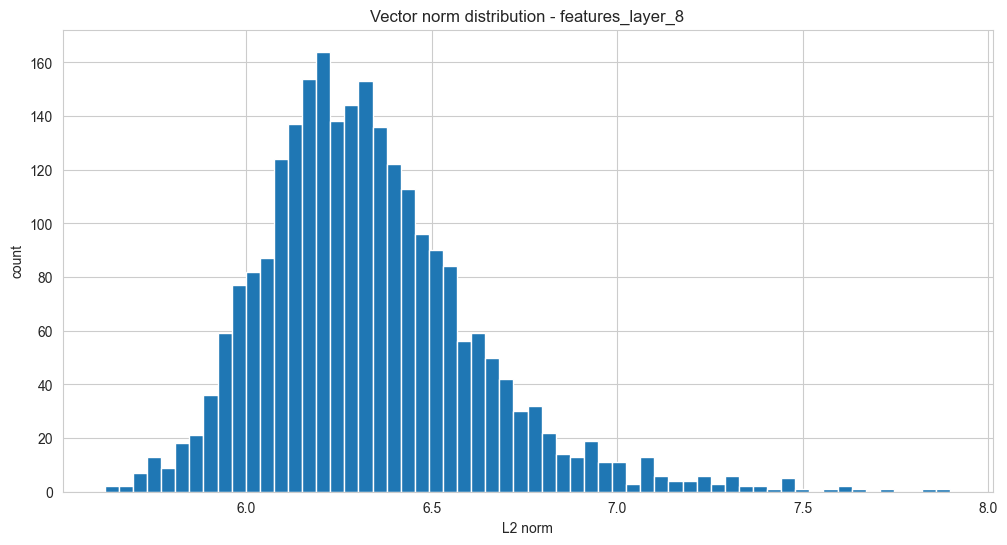

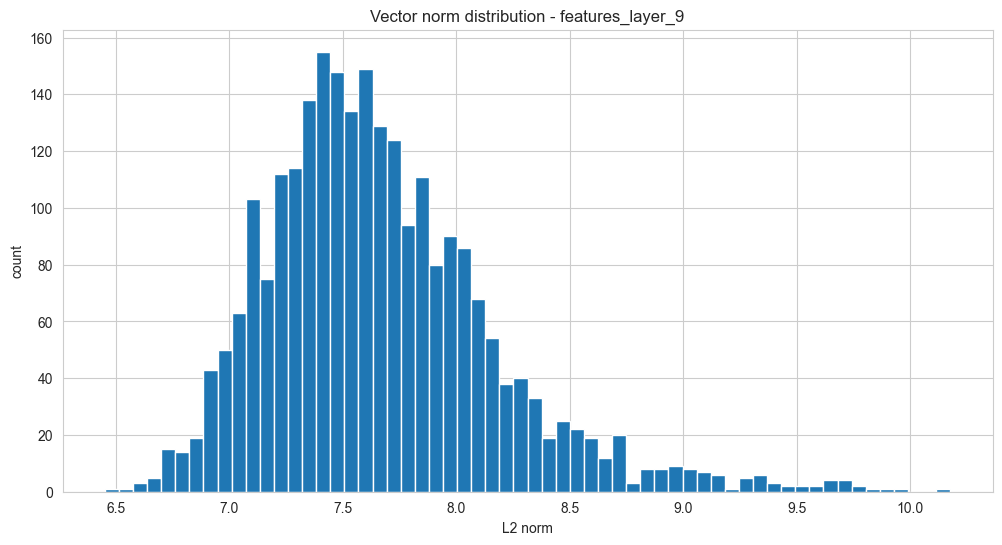

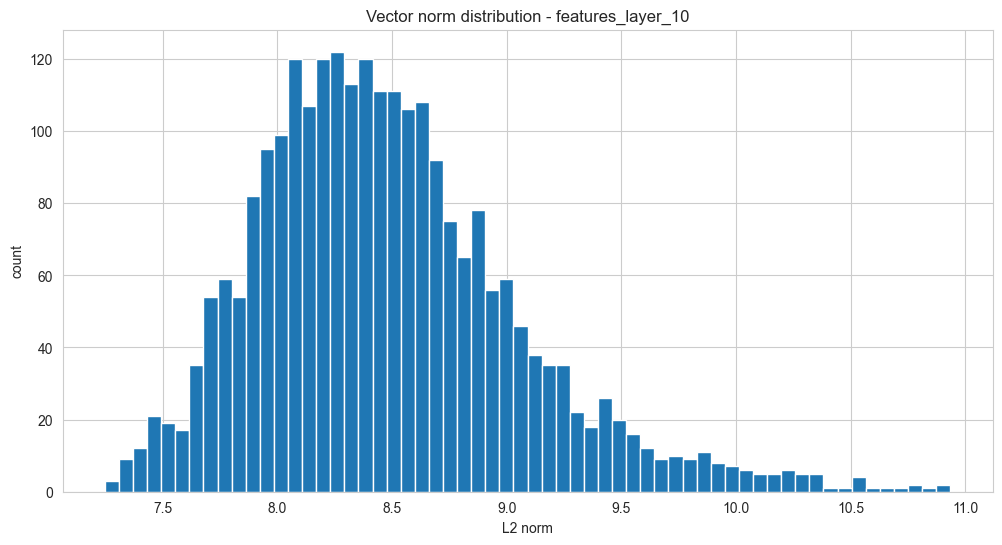

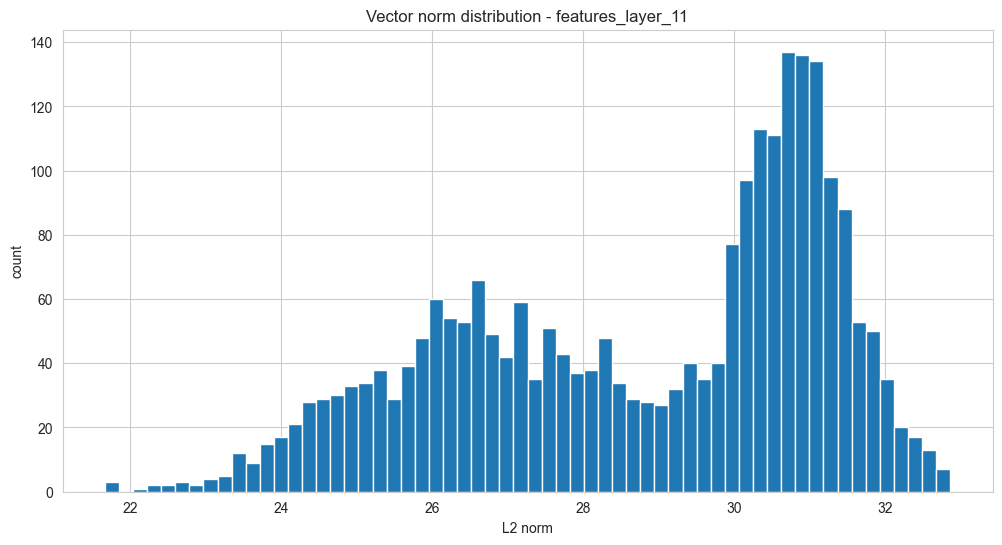

In [5]:
def plot_norm_hist(features_by_layer, bins=60):
    for ln, X in features_by_layer.items():
        X = np.asarray(X)
        norms = np.linalg.norm(X, axis=1)
        plt.figure()
        plt.hist(norms, bins=bins)
        plt.title(f"Vector norm distribution - {ln}")
        plt.xlabel("L2 norm")
        plt.ylabel("count")
        plt.show()

plot_norm_hist(features_by_layer)


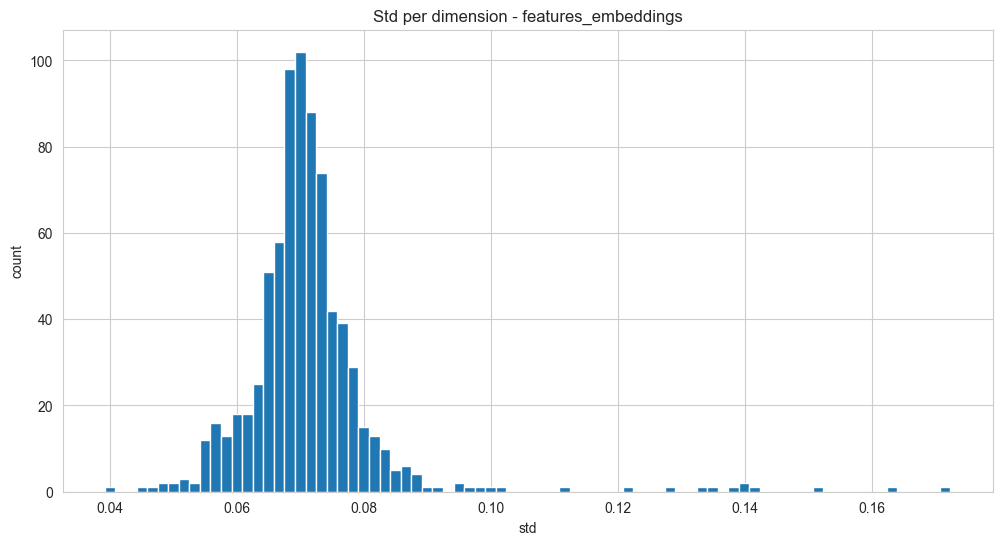

features_embeddings dims ~constant: 0


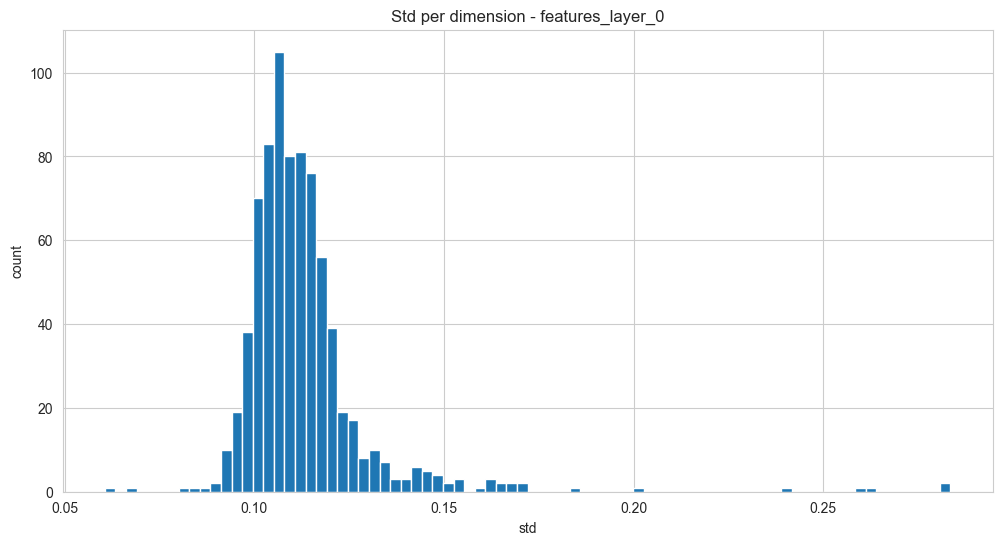

features_layer_0 dims ~constant: 0


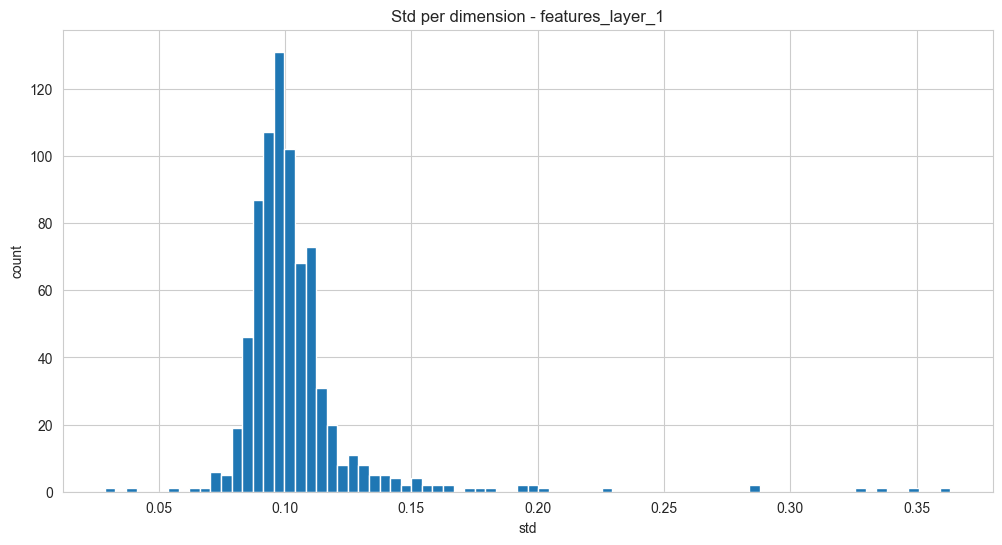

features_layer_1 dims ~constant: 0


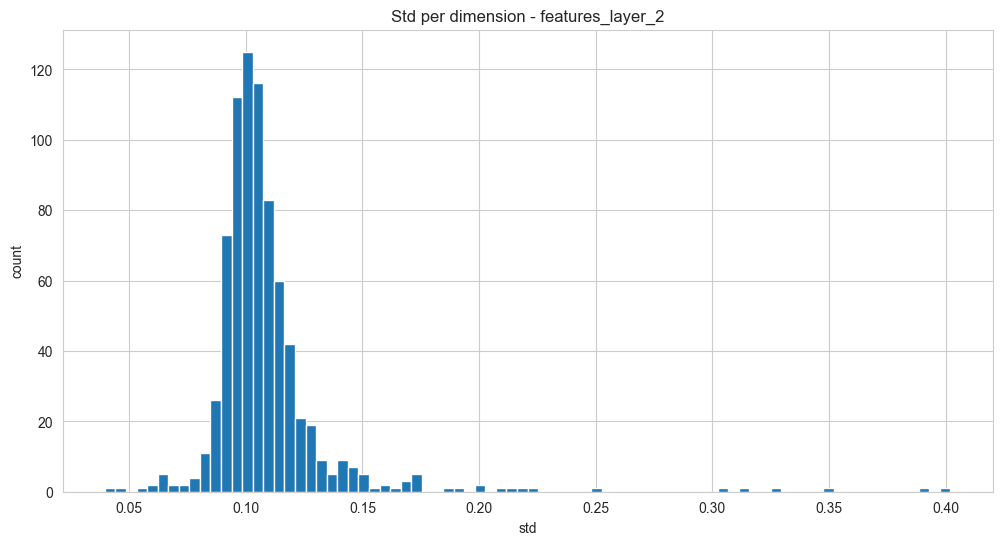

features_layer_2 dims ~constant: 0


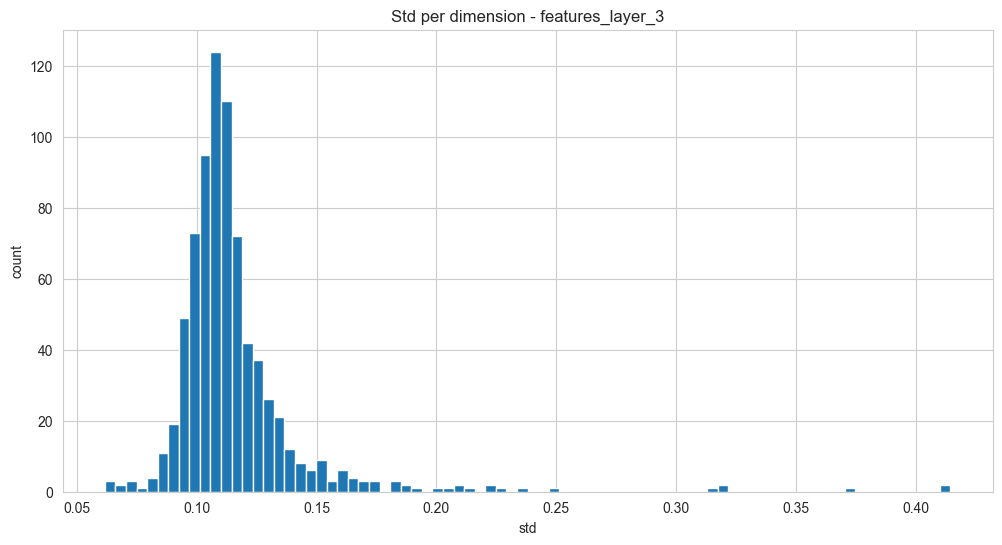

features_layer_3 dims ~constant: 0


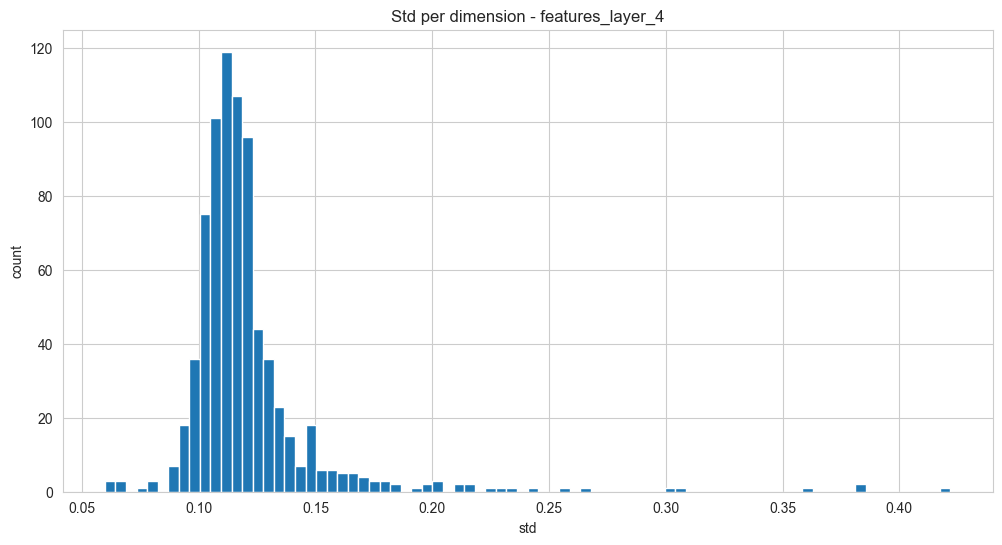

features_layer_4 dims ~constant: 0


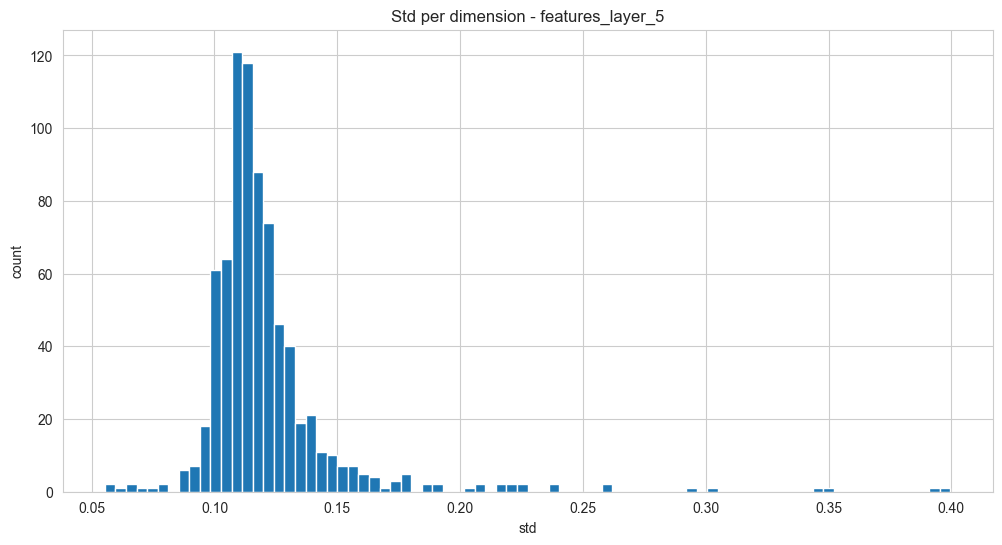

features_layer_5 dims ~constant: 0


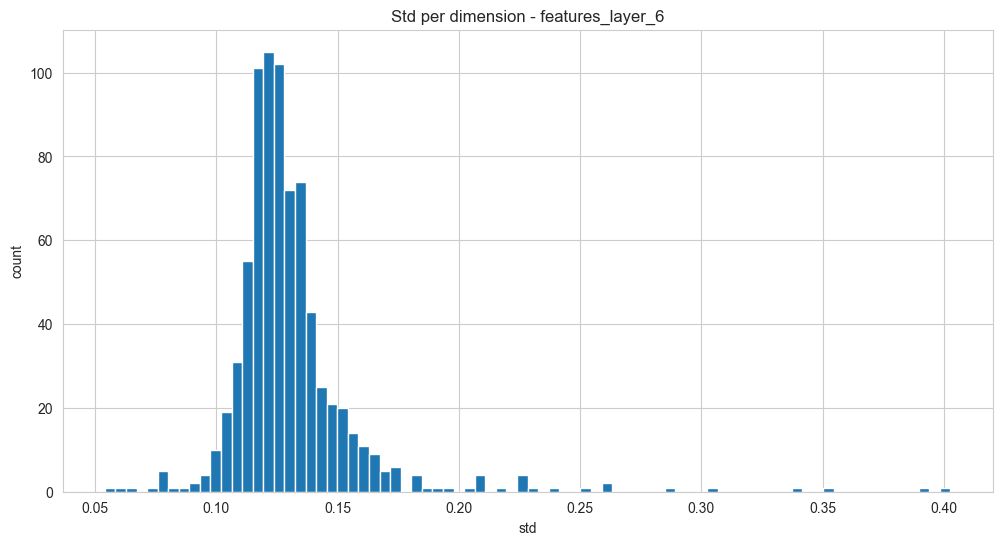

features_layer_6 dims ~constant: 0


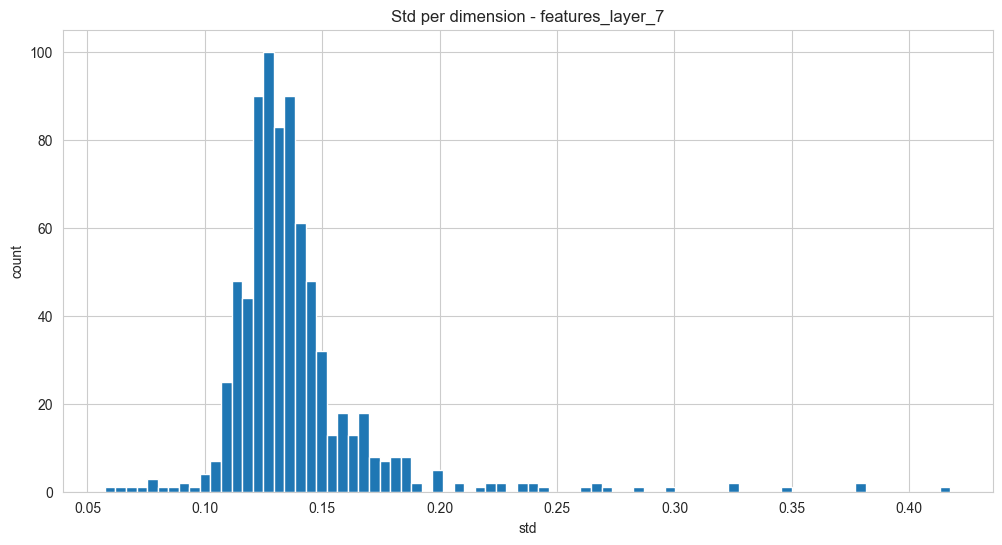

features_layer_7 dims ~constant: 0


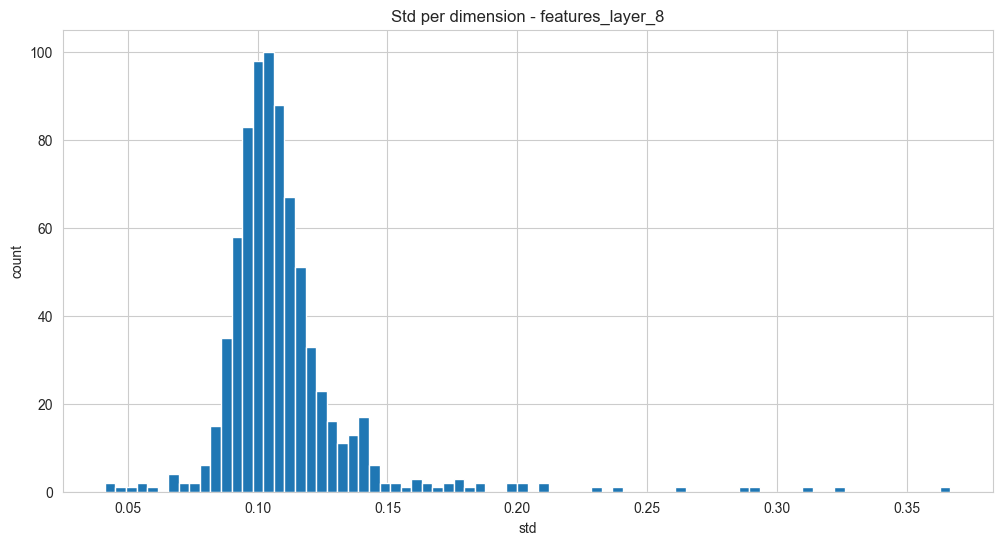

features_layer_8 dims ~constant: 0


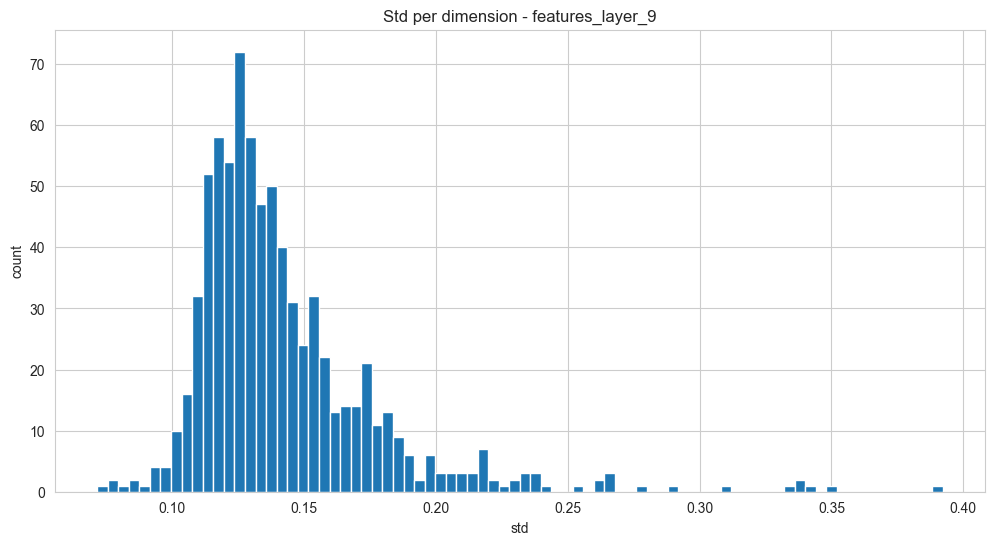

features_layer_9 dims ~constant: 0


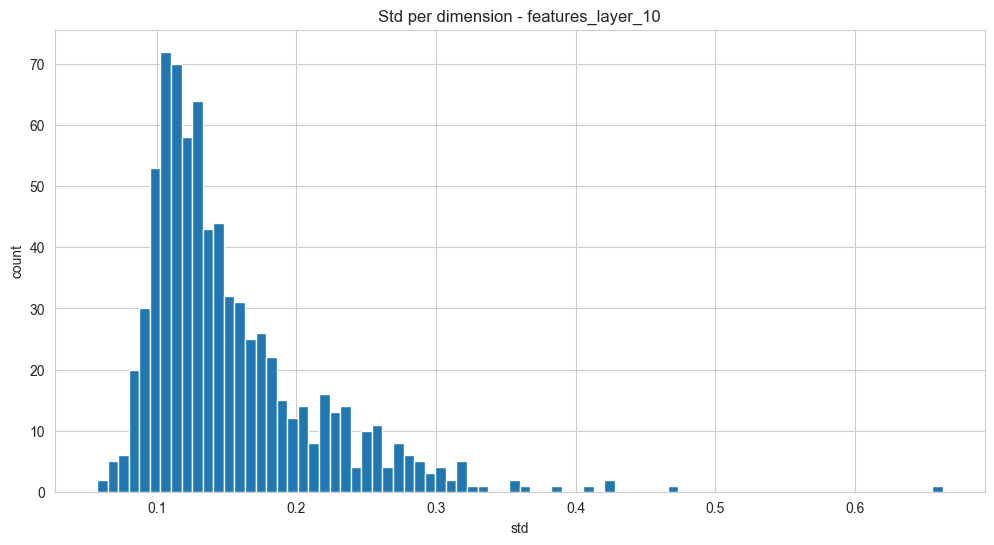

features_layer_10 dims ~constant: 0


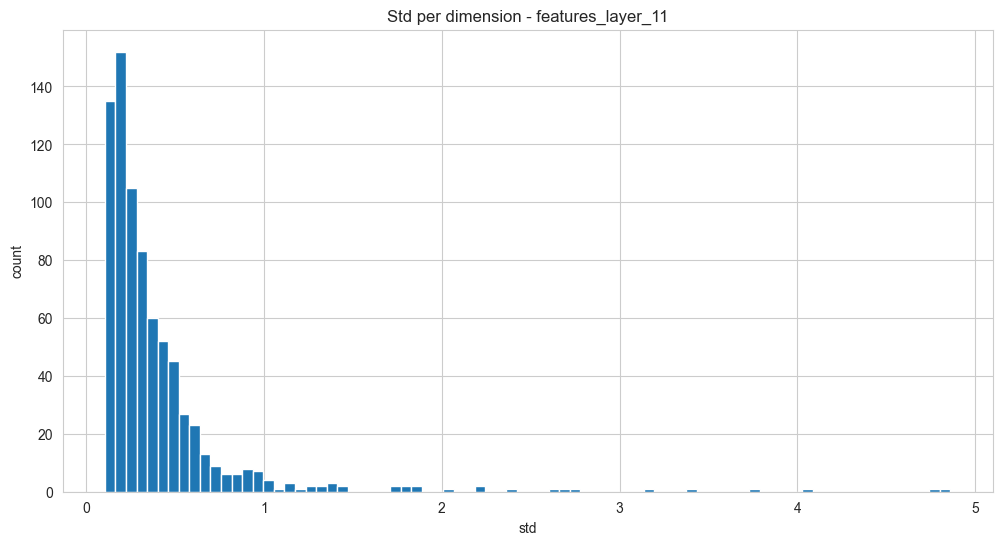

features_layer_11 dims ~constant: 0


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_std_per_dim(X, title=""):
    # X: [N, D]
    std = X.std(axis=0)
    plt.figure()
    plt.hist(std, bins=80)
    plt.title(f"Std per dimension {title}")
    plt.xlabel("std")
    plt.ylabel("count")
    plt.show()
    return std

for ln, X in features_by_layer.items():
    X = np.asarray(X)
    std = plot_std_per_dim(X, title=f"- {ln}")
    print(ln, "dims ~constant:", int((std < 1e-8).sum()))


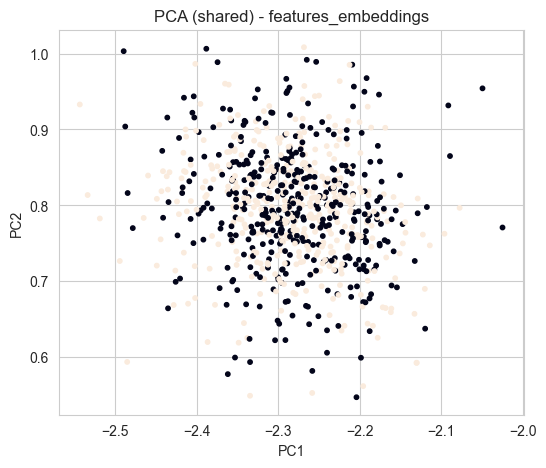

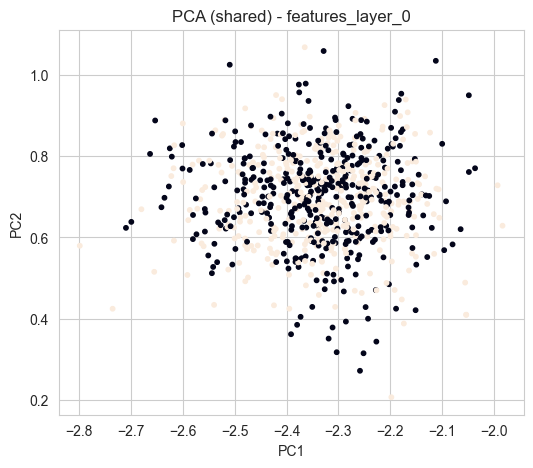

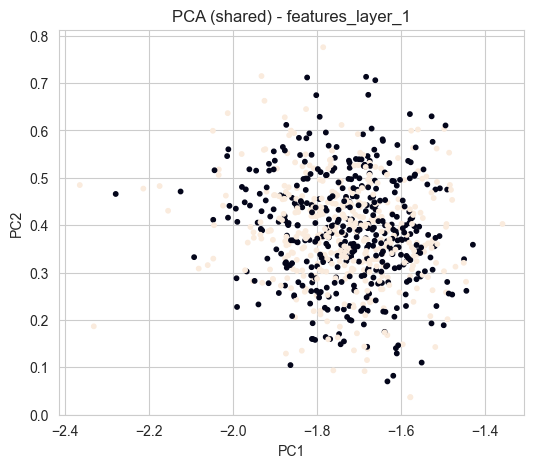

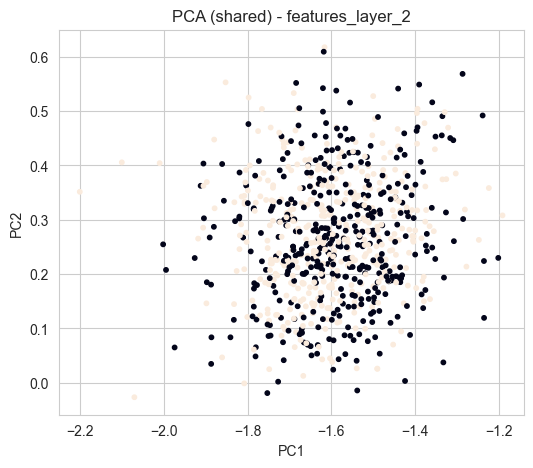

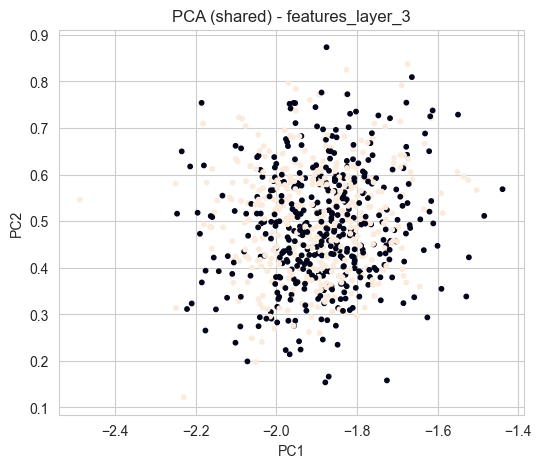

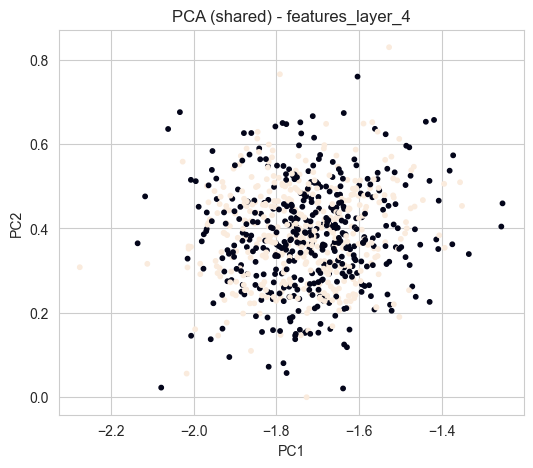

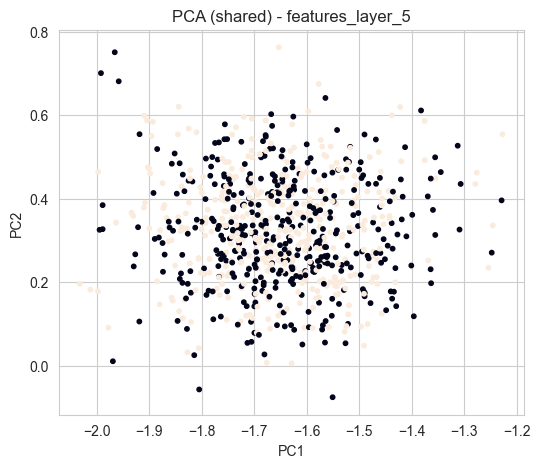

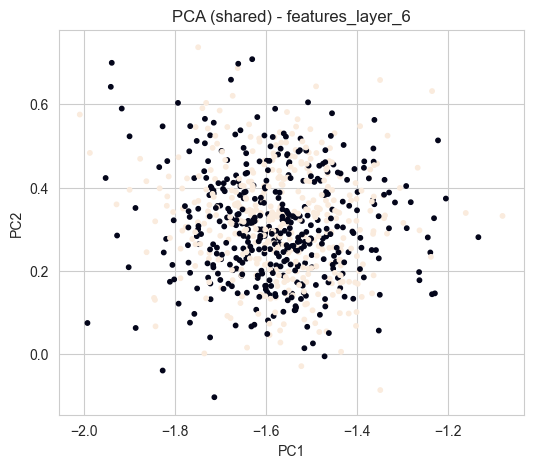

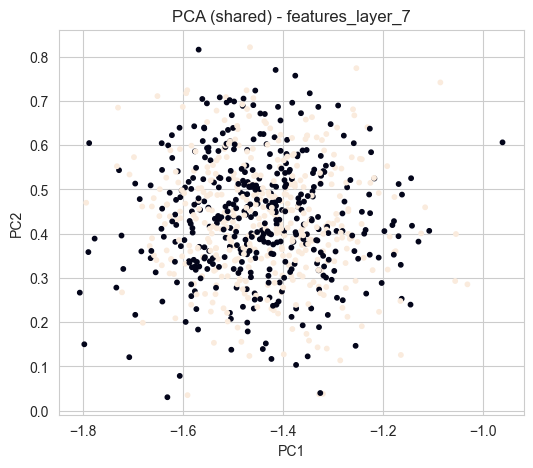

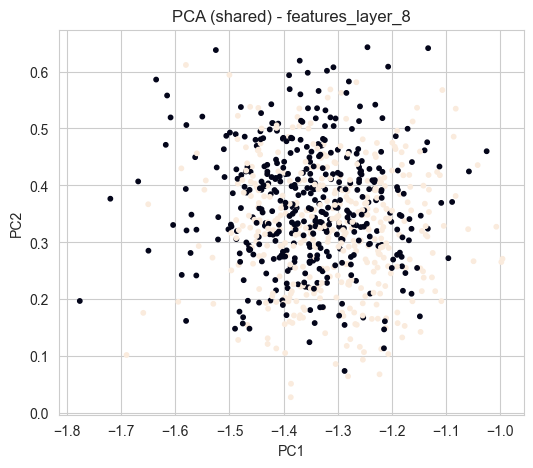

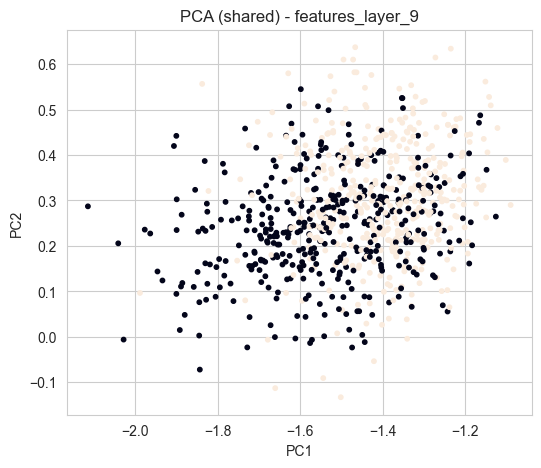

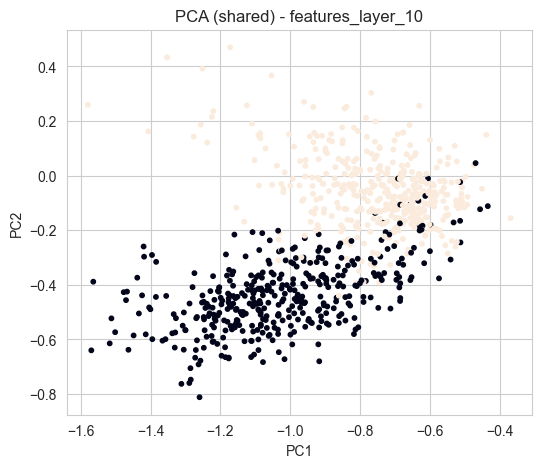

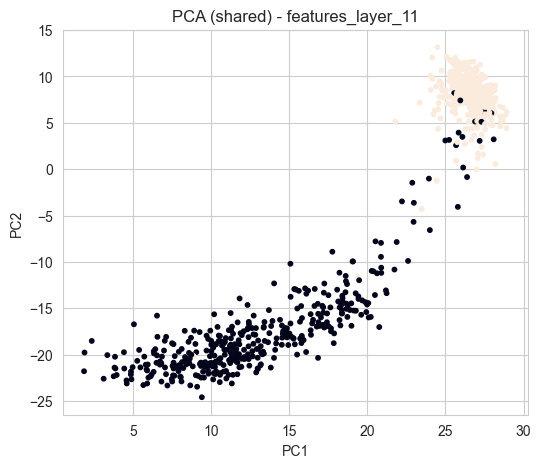

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

idx = np.random.choice(len(labels_all), size=min(800, len(labels_all)), replace=False)
y = labels_all[idx]

layer_names = list(features_by_layer.keys())

X_fit = np.vstack([np.asarray(features_by_layer[ln])[idx] for ln in layer_names])
pca = PCA(n_components=2, random_state=0).fit(X_fit)

for ln in layer_names:
    X = np.asarray(features_by_layer[ln])[idx]
    X2 = pca.transform(X)

    plt.figure(figsize=(6, 5))
    plt.scatter(X2[:, 0], X2[:, 1], s=10, c=y)
    plt.title(f"PCA (shared) - {ln}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()


In [103]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

idx = np.random.choice(len(labels_all), size=min(800, len(labels_all)), replace=False)
y = labels_all[idx]

X = np.asarray(features_by_layer["layer_11"])[idx]

for k in [2, 5, 10, 20, 50, 100, 200]:
    Xk = PCA(n_components=k, random_state=0).fit_transform(X)
    s = silhouette_score(Xk, y)
    print(f"PCA-{k}: silhouette = {s:.4f}")


PCA-2: silhouette = 0.0001
PCA-5: silhouette = 0.0010
PCA-10: silhouette = 0.0017
PCA-20: silhouette = 0.0013
PCA-50: silhouette = 0.0011
PCA-100: silhouette = 0.0010
PCA-200: silhouette = 0.0010


In [104]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

idx = np.random.choice(len(labels_all), size=min(800, len(labels_all)), replace=False)
y = labels_all[idx]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

scores = []
for ln in layer_names:
    X = np.asarray(features_by_layer[ln])[idx]
    clf = LogisticRegression(max_iter=3000)
    acc = cross_val_score(clf, X, y, cv=cv, scoring="accuracy").mean()
    scores.append((ln, acc))

scores_sorted = sorted(scores, key=lambda x: x[1], reverse=True)
print("Top layers by linear probe accuracy:")
for ln, acc in scores_sorted[:5]:
    print(ln, acc)

print("\nWorst layers:")
for ln, acc in scores_sorted[-5:]:
    print(ln, acc)


Top layers by linear probe accuracy:
layer_7 0.5887499999999999
layer_11 0.58375
layer_8 0.57625
layer_10 0.575
layer_2 0.56875

Worst layers:
layer_4 0.5599999999999999
layer_9 0.5599999999999999
layer_1 0.54
layer_0 0.515
embeddings 0.49749999999999994


In [95]:
import numpy as np

layer_names = list(features_by_layer.keys())
idx2 = idx[:200]  # pequeno

mus = [np.asarray(features_by_layer[ln])[idx2].mean(axis=0) for ln in layer_names]
deltas = [np.linalg.norm(mus[i+1]-mus[i]) for i in range(len(mus)-1)]
print("mean delta between consecutive layers:", np.mean(deltas), "min:", np.min(deltas), "max:", np.max(deltas))


mean delta between consecutive layers: 3.5614731 min: 1.4941598 max: 10.198605


In [93]:
def stack_layers(features_by_layer):
    layer_names = list(features_by_layer.keys())
    Xs = [np.asarray(features_by_layer[ln]) for ln in layer_names]  # each [N,D]
    X = np.stack(Xs, axis=0)  # [L,N,D]
    return layer_names, X

def invariant_dims_by_mean_across_layers(features_by_layer, eps=1e-12):
    layer_names, X = stack_layers(features_by_layer)  # [L,N,D]
    mu = X.mean(axis=1)  # [L,D]  mean over samples
    var_across_layers = np.var(mu, axis=0)  # [D]
    mask = var_across_layers < eps
    return layer_names, mask, var_across_layers

layer_names, inv_mask, v = invariant_dims_by_mean_across_layers(features_by_layer, eps=1e-10)
print("Dims with near-invariant mean across layers:", int(inv_mask.sum()))
print("Example dims:", np.where(inv_mask)[0][:10])


Dims with near-invariant mean across layers: 0
Example dims: []


In [94]:
def invariant_dims_strong(features_by_layer, eps=1e-10):
    _, X = stack_layers(features_by_layer)  # [L,N,D]
    # var ao longo dos layers para cada (N,D)
    var_ln = np.var(X, axis=0)  # [N,D]
    # agrega sobre N: se a dimensão tem var pequena para a maioria das amostras
    frac_small = np.mean(var_ln < eps, axis=0)  # [D] fração de amostras com var pequena
    return frac_small

frac_small = invariant_dims_strong(features_by_layer, eps=1e-10)
# dims que são quase invariantes para >= 95% das amostras
dims = np.where(frac_small >= 0.95)[0]
print("Strong-invariant dims (>=95% samples):", len(dims))
print("Example:", dims[:10])


Strong-invariant dims (>=95% samples): 0
Example: []


## 7. Teste 4: Extração de Metafeatures (Opcional - pode demorar)


In [2]:
import numpy as np

loaded_data = np.load('../data/features/full_rte_allsplits_features.npz', allow_pickle=True)

print("Available arrays in the file:", loaded_data.files)

# keys you want (all layers + embeddings, but not labels)
feature_keys = [k for k in loaded_data.files if k.startswith("features_")]

# load train lines from each
full_dataset = {k: loaded_data[k][:2490] for k in feature_keys}
labels = loaded_data["labels"][:2490]

for k, v in full_dataset.items():
    print(f"{k}: {v.shape}")

print("labels:", labels.shape)


Available arrays in the file: ['features_embeddings', 'features_layer_0', 'features_layer_1', 'features_layer_2', 'features_layer_3', 'features_layer_4', 'features_layer_5', 'features_layer_6', 'features_layer_7', 'features_layer_8', 'features_layer_9', 'features_layer_10', 'features_layer_11', 'labels']
features_embeddings: (2490, 768)
features_layer_0: (2490, 768)
features_layer_1: (2490, 768)
features_layer_2: (2490, 768)
features_layer_3: (2490, 768)
features_layer_4: (2490, 768)
features_layer_5: (2490, 768)
features_layer_6: (2490, 768)
features_layer_7: (2490, 768)
features_layer_8: (2490, 768)
features_layer_9: (2490, 768)
features_layer_10: (2490, 768)
features_layer_11: (2490, 768)
labels: (2490,)


In [22]:
model = RobertaForSequenceClassification.from_pretrained("../pretrained_models/roberta_rte_finetuned_best")

model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)

extractor = FeaturesExtraction(model, tokenizer)

# Função de tokenização para o dataset RTE
def tokenize_rte(tokenizer, batch, max_length):
    """Tokeniza pares de sentenças para a tarefa RTE."""
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        padding="longest",
        truncation=True,
        max_length=max_length,
    )

print("✅ Função de tokenização definida")


2026-01-27 10:17:04 [INFO] features_extraction.core: Initialized FeaturesExtraction with model=RobertaForSequenceClassification, tokenizer=RobertaTokenizer


✅ Função de tokenização definida


In [31]:
meta_config = MetaFeatureConfig(
    groups=["complexity"],
    summaries=None,  # Get raw values without summarization
    dataset_name="rte_test",
    token_reduce="mean"
)

# When passing a dict of features, use 'labels' instead of 'tokenize_fn'
meta_df = extractor.extract_all_layers_and_metafeatures(
    dataset=full_dataset,  # dict of features
    labels=labels,     # labels for first 5 instances
    meta_config=meta_config
    # No tokenize_fn needed
    # No extraction_config needed
)

print(f"Shape: {meta_df.shape}")
print(f"Columns: {meta_df.columns.tolist()}")
print(meta_df.head(20))


2026-01-21 12:42:54 [INFO] features_extraction.utils: Starting extract_all_layers_and_metafeatures
2026-01-21 12:42:54 [INFO] features_extraction.core: Using pre-extracted features from dict
2026-01-21 12:42:54 [INFO] features_extraction.core: Extracting meta-features for 13 layers
2026-01-21 12:42:54 [INFO] features_extraction.metafeatures: Extracting meta-features: X.shape=(2490, 768), y.shape=(2490,), groups=['complexity']
2026-01-21 12:42:54 [INFO] features_extraction.metafeatures: Extracting 1 meta-feature groups
2026-01-21 12:47:25 [INFO] features_extraction.metafeatures: Extracted 22 features for group 'complexity'
2026-01-21 12:47:25 [INFO] features_extraction.metafeatures: Extracted 22 meta-features
2026-01-21 12:47:25 [INFO] features_extraction.metafeatures: Extracting meta-features: X.shape=(2490, 768), y.shape=(2490,), groups=['complexity']
2026-01-21 12:47:25 [INFO] features_extraction.metafeatures: Extracting 1 meta-feature groups
2026-01-21 12:52:05 [INFO] features_extra

Shape: (286, 5)
Columns: ['feature', 'value', 'group', 'dataset', 'layer']
     feature                                              value       group  \
0         c1                                           0.999993  complexity   
1         c2                                           0.000021  complexity   
2   cls_coef                                             0.5024  complexity   
3    density                                           0.880643  complexity   
4         f1  [0.9996307904621666, 0.9999528581262097, 0.999...  complexity   
5        f1v                               [0.3366688307580065]  complexity   
6         f2                            [9.318661540982744e-46]  complexity   
7         f3                               [0.9931726907630523]  complexity   
8         f4                                              [0.0]  complexity   
9       hubs  [0.7660563018780328, 0.9999999999999998, 0.999...  complexity   
10        l1                              [0.18754144260

In [ ]:
import numpy as np

np.savez_compressed("metafeatures_rte.npz", df=meta_df.to_numpy(), columns=meta_df.columns.to_numpy())


In [19]:
import pandas as pd

# Show all rows + all columns (careful: can be huge)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Don’t truncate long text in cells
pd.reset_option("display.max_colwidth")

# Prevent wrapping to multiple lines (optional)
pd.set_option("display.expand_frame_repr", False)


In [21]:

# Load the compressed npz file
data = np.load("metafeatures_rte.npz", allow_pickle=True)

# Extract the DataFrame values and columns
df_values = data["df"]
columns = data["columns"]

# Reconstruct the DataFrame
import pandas as pd
meta_df = pd.DataFrame(df_values, columns=columns)

display(meta_df)

,feature,value,group,dataset,layer
0,c1,0.999993,complexity,rte_test,features_embeddings
1,c2,0.000021,complexity,rte_test,features_embeddings
2,cls_coef,0.5024,complexity,rte_test,features_embeddings
3,density,0.880643,complexity,rte_test,features_embeddings
4,f1,"[0.9996307904621666, 0.9999528581262097, 0.999...",complexity,rte_test,features_embeddings
5,f1v,[0.3366688307580065],complexity,rte_test,features_embeddings
6,f2,[9.318661540982744e-46],complexity,rte_test,features_embeddings
7,f3,[0.9931726907630523],complexity,rte_test,features_embeddings
8,f4,[0.0],complexity,rte_test,features_embeddings
9,hubs,"[0.7660563018780328, 0.9999999999999998, 0.999...",complexity,rte_test,features_embeddings


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:

def plot_feature_boxplot_by_layer(meta_df, feature_name, group="complexity", dataset=None,
                                  sort_layers=True, showfliers=False, figsize=(12, 6)):
    df = meta_df.copy()

    # Optional filters
    if group is not None and "group" in df.columns:
        df = df[df["group"] == group]
    if dataset is not None and "dataset" in df.columns:
        df = df[df["dataset"] == dataset]

    # Filter to the feature
    df = df[df["feature"] == feature_name].copy()
    if df.empty:
        raise ValueError(f"No rows found for feature='{feature_name}' with the given filters.")

    # Ensure "value" is list-like for explode
    def to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, list):
            return v
        # scalar -> list with one element (so explode still works)
        return [v]

    df["value"] = df["value"].apply(to_list)
    df = df.explode("value", ignore_index=True)

    # Convert to numeric, drop bad rows
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])

    # Sort layers in a nice order: embeddings first, then layer_0..layer_11
    layers = df["layer"].unique().tolist()
    if sort_layers:
        def layer_key(x):
            if x == "features_embeddings":
                return (-1, -1)
            if isinstance(x, str) and x.startswith("features_layer_"):
                try:
                    return (0, int(x.split("_")[-1]))
                except Exception:
                    pass
            return (1, str(x))
        layers = sorted(layers, key=layer_key)
    layers = ["features_input" if n == "features_embeddings" else n for n in layers]

    data = [df.loc[df["layer"] == L, "value"].values for L in layers]

    plt.figure(figsize=figsize)
    plt.boxplot(data, labels=layers, showfliers=showfliers)
    plt.title(f"{feature_name}: distribution by layer")
    plt.xlabel("Layer")
    plt.ylabel("Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

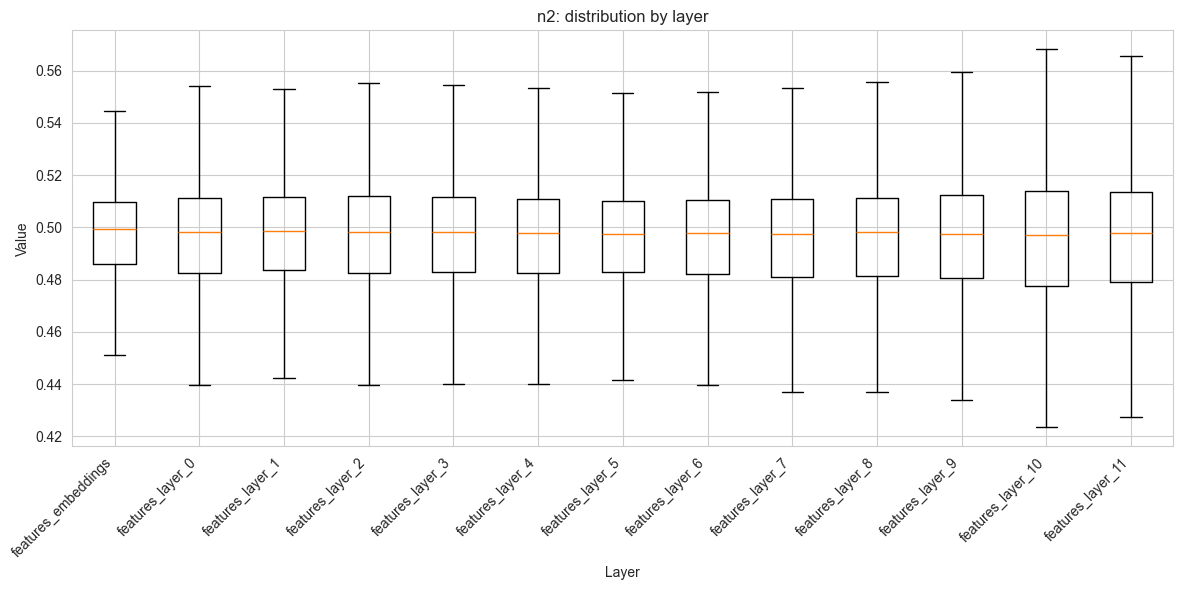

In [ ]:
# Example: f1 across all layers
plot_feature_boxplot_by_layer(meta_df, feature_name="n2", dataset="rte_test")


In [6]:
plot_feature_boxplot_by_layer(full_dataset, feature_name="features", dataset="rte_test")


AttributeError: 'dict' object has no attribute 'columns'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_boxplot_by_layer(meta_df, feature_name, group="complexity", dataset=None,
                                  sort_layers=True, showfliers=False, figsize=(12, 6)):
    """
    Plot a boxplot of a specific feature's distribution across layers.

    Args:
        meta_df (pd.DataFrame): DataFrame containing meta-features with columns 'feature', 'value', and 'layer'.
        feature_name (str): Name of the feature to plot.
        group (str, optional): Filter by group. Defaults to "complexity".
        dataset (str, optional): Filter by dataset name. Defaults to None.
        sort_layers (bool, optional): Whether to sort layers in ascending order. Defaults to True.
        showfliers (bool, optional): Whether to show outliers in the boxplot. Defaults to False.
        figsize (tuple, optional): Figure size. Defaults to (12, 6).
    """
    df = meta_df.copy()

    # Optional filters
    if group is not None and "group" in df.columns:
        df = df[df["group"] == group]
    if dataset is not None and "dataset" in df.columns:
        df = df[df["dataset"] == dataset]

    # Filter to the feature
    df = df[df["feature"] == feature_name].copy()
    if df.empty:
        raise ValueError(f"No rows found for feature='{feature_name}' with the given filters.")

    # Ensure "value" is list-like for explode
    def to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, list):
            return v
        # scalar -> list with one element (so explode still works)
        return [v]

    df["value"] = df["value"].apply(to_list)
    df = df.explode("value", ignore_index=True)

    # Convert to numeric, drop bad rows
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])

    # Sort layers in a nice order: embeddings first, then layer_0..layer_11
    layers = df["layer"].unique().tolist()
    if sort_layers:
        def layer_key(x):
            if x == "features_embeddings":
                return (-1, -1)
            if isinstance(x, str) and x.startswith("features_layer_"):
                try:
                    return (0, int(x.split("_")[-1]))
                except Exception:
                    pass
            return (1, str(x))
        layers = sorted(layers, key=layer_key)
    layers = ["features_input" if n == "features_embeddings" else n for n in layers]

    data = [df.loc[df["layer"] == L, "value"].values for L in layers]

    plt.figure(figsize=figsize)
    plt.boxplot(data, labels=layers, showfliers=showfliers)
    plt.title(f"{feature_name}: distribution by layer")
    plt.xlabel("Layer")
    plt.ylabel("Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Example usage
plot_feature_boxplot_by_layer(meta_df, feature_name="f1", group="complexity")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_boxplot_by_layer_from_npz(npz_file_path, feature_name, group="complexity", dataset=None,
                                           sort_layers=True, showfliers=False, figsize=(12, 6)):
    """
    Plot a boxplot of a specific feature's distribution across layers from an NPZ file.

    Args:
        npz_file_path (str): Path to the NPZ file containing features.
        feature_name (str): Name of the feature to plot.
        group (str, optional): Filter by group. Defaults to "complexity".
        dataset (str, optional): Filter by dataset name. Defaults to None.
        sort_layers (bool, optional): Whether to sort layers in ascending order. Defaults to True.
        showfliers (bool, optional): Whether to show outliers in the boxplot. Defaults to False.
        figsize (tuple, optional): Figure size. Defaults to (12, 6).
    """
    # Load the NPZ file
    loaded_data = np.load(npz_file_path, allow_pickle=True)

    # Extract feature keys and labels
    feature_keys = [k for k in loaded_data.files if k.startswith("features_")]
    full_dataset = {k: loaded_data[k][:2490] for k in feature_keys}
    labels = loaded_data["labels"][:2490]

    # Convert the dataset into a DataFrame
    data = []
    for layer, values in full_dataset.items():
        for instance_values in values:
            data.append({"layer": layer, "value": instance_values})

    meta_df = pd.DataFrame(data)

    # Filter to the feature
    df = meta_df[meta_df["layer"] == feature_name].copy()
    if df.empty:
        raise ValueError(f"No rows found for feature='{feature_name}' with the given filters.")

    # Ensure "value" is list-like for explode
    def to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, list):
            return v
        # scalar -> list with one element (so explode still works)
        return [v]

    df["value"] = df["value"].apply(to_list)
    df = df.explode("value", ignore_index=True)

    # Convert to numeric, drop bad rows
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])

    # Sort layers in a nice order: embeddings first, then layer_0..layer_11
    layers = df["layer"].unique().tolist()
    if sort_layers:
        def layer_key(x):
            if x == "features_embeddings":
                return (-1, -1)
            if isinstance(x, str) and x.startswith("features_layer_"):
                try:
                    return (0, int(x.split("_")[-1]))
                except Exception:
                    pass
            return (1, str(x))
        layers = sorted(layers, key=layer_key)
    layers = ["features_input" if n == "features_embeddings" else n for n in layers]

    data = [df.loc[df["layer"] == L, "value"].values for L in layers]

    plt.figure(figsize=figsize)
    plt.boxplot(data, labels=layers, showfliers=showfliers)
    plt.title(f"{feature_name}: distribution by layer")
    plt.xlabel("Layer")
    plt.ylabel("Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Example usage
plot_feature_boxplot_by_layer_from_npz(
    npz_file_path="../data/features/full_rte_allsplits_features.npz",
    feature_name="features_layer_0",
    group="complexity"
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_boxplot_by_layer_from_npz_v2(npz_file_path, feature_name, sort_layers=True, showfliers=False, figsize=(12, 6)):
    """
    Plot a boxplot of a specific feature's distribution across layers from an NPZ file.

    Args:
        npz_file_path (str): Path to the NPZ file containing features.
        feature_name (str): Name of the feature to plot.
        sort_layers (bool, optional): Whether to sort layers in ascending order. Defaults to True.
        showfliers (bool, optional): Whether to show outliers in the boxplot. Defaults to False.
        figsize (tuple, optional): Figure size. Defaults to (12, 6).
    """
    # Load the NPZ file
    loaded_data = np.load(npz_file_path, allow_pickle=True)

    print("Available arrays in the file:", loaded_data.files)

    # Extract feature keys and labels
    feature_keys = [k for k in loaded_data.files if k.startswith("features_")]
    full_dataset = {k: loaded_data[k][:2490] for k in feature_keys}

    # Convert the dataset into a DataFrame
    data = []
    for layer, values in full_dataset.items():
        for instance_values in values:
            data.append({"layer": layer, "value": instance_values})

    meta_df = pd.DataFrame(data)

    # Filter to the feature
    df = meta_df[meta_df["layer"] == feature_name].copy()
    if df.empty:
        raise ValueError(f"No rows found for feature='{feature_name}' in the dataset.")

    # Ensure "value" is list-like for explode
    def to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, list):
            return v
        # scalar -> list with one element (so explode still works)
        return [v]

    df["value"] = df["value"].apply(to_list)
    df = df.explode("value", ignore_index=True)

    # Convert to numeric, drop bad rows
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])

    # Sort layers in a nice order: embeddings first, then layer_0..layer_11
    layers = df["layer"].unique().tolist()
    if sort_layers:
        def layer_key(x):
            if x == "features_embeddings":
                return (-1, -1)
            if isinstance(x, str) and x.startswith("features_layer_"):
                try:
                    return (0, int(x.split("_")[-1]))
                except Exception:
                    pass
            return (1, str(x))
        layers = sorted(layers, key=layer_key)
    layers = ["features_input" if n == "features_embeddings" else n for n in layers]

    data = [df.loc[df["layer"] == L, "value"].values for L in layers]

    plt.figure(figsize=figsize)
    plt.boxplot(data, labels=layers, showfliers=showfliers)
    plt.title(f"{feature_name}: distribution by layer")
    plt.xlabel("Layer")
    plt.ylabel("Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Example usage
plot_feature_boxplot_by_layer_from_npz_v2(
    npz_file_path="../data/features/full_rte_allsplits_features.npz",
    feature_name="features_layer_0"
)

Available arrays in the file: ['features_embeddings', 'features_layer_0', 'features_layer_1', 'features_layer_2', 'features_layer_3', 'features_layer_4', 'features_layer_5', 'features_layer_6', 'features_layer_7', 'features_layer_8', 'features_layer_9', 'features_layer_10', 'features_layer_11', 'labels']


/var/folders/ff/lyy0zjdd1gz_gpdk3cpwnlpw0000gn/T/ipykernel_16759/3564714806.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=layers, showfliers=showfliers)


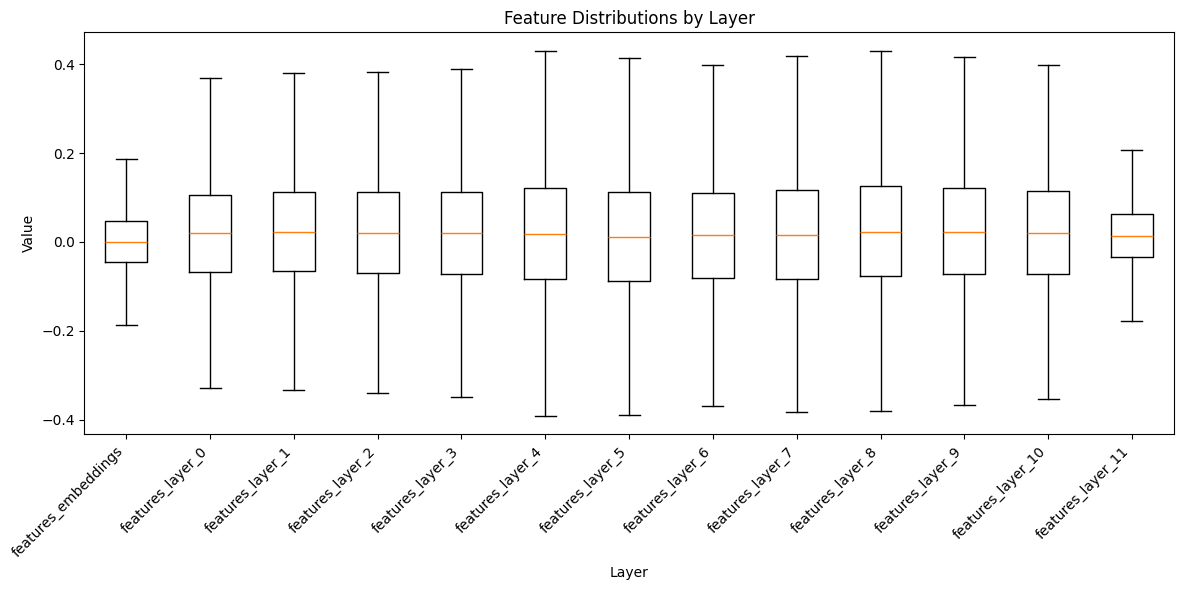

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_boxplot_by_layer_from_npz_v3(npz_file_path, sort_layers=True, showfliers=False, figsize=(12, 6)):
    """
    Plot boxplots of all features' distributions across layers from an NPZ file.

    Args:
        npz_file_path (str): Path to the NPZ file containing features.
        sort_layers (bool, optional): Whether to sort layers in ascending order. Defaults to True.
        showfliers (bool, optional): Whether to show outliers in the boxplot. Defaults to False.
        figsize (tuple, optional): Figure size. Defaults to (12, 6).
    """
    # Load the NPZ file
    loaded_data = np.load(npz_file_path, allow_pickle=True)

    print("Available arrays in the file:", loaded_data.files)

    # Extract feature keys and labels
    feature_keys = [k for k in loaded_data.files if k.startswith("features_")]
    full_dataset = {k: loaded_data[k][:2490] for k in feature_keys}

    # Convert the dataset into a DataFrame
    data = []
    for layer, values in full_dataset.items():
        for instance_values in values:
            data.append({"layer": layer, "value": instance_values})

    meta_df = pd.DataFrame(data)

    # Ensure "value" is list-like for explode
    def to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, list):
            return v
        # scalar -> list with one element (so explode still works)
        return [v]

    meta_df["value"] = meta_df["value"].apply(to_list)
    meta_df = meta_df.explode("value", ignore_index=True)

    # Convert to numeric, drop bad rows
    meta_df["value"] = pd.to_numeric(meta_df["value"], errors="coerce")
    meta_df = meta_df.dropna(subset=["value"])

    # Sort layers in a nice order: embeddings first, then layer_0..layer_11
    layers = meta_df["layer"].unique().tolist()
    if sort_layers:
        def layer_key(x):
            if x == "features_embeddings":
                return (-1, -1)
            if isinstance(x, str) and x.startswith("features_layer_"):
                try:
                    return (0, int(x.split("_")[-1]))
                except Exception:
                    pass
            return (1, str(x))
        layers = sorted(layers, key=layer_key)
    layers = ["features_input" if n == "features_embeddings" else n for n in layers]

    data = [meta_df.loc[meta_df["layer"] == L, "value"].values for L in layers]

    plt.figure(figsize=figsize)
    plt.boxplot(data, labels=layers, showfliers=showfliers)
    plt.title("Feature Distributions by Layer")
    plt.xlabel("Layer")
    plt.ylabel("Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Example usage
plot_feature_boxplot_by_layer_from_npz_v3(
    npz_file_path="../data/features/full_rte_allsplits_features.npz"
)

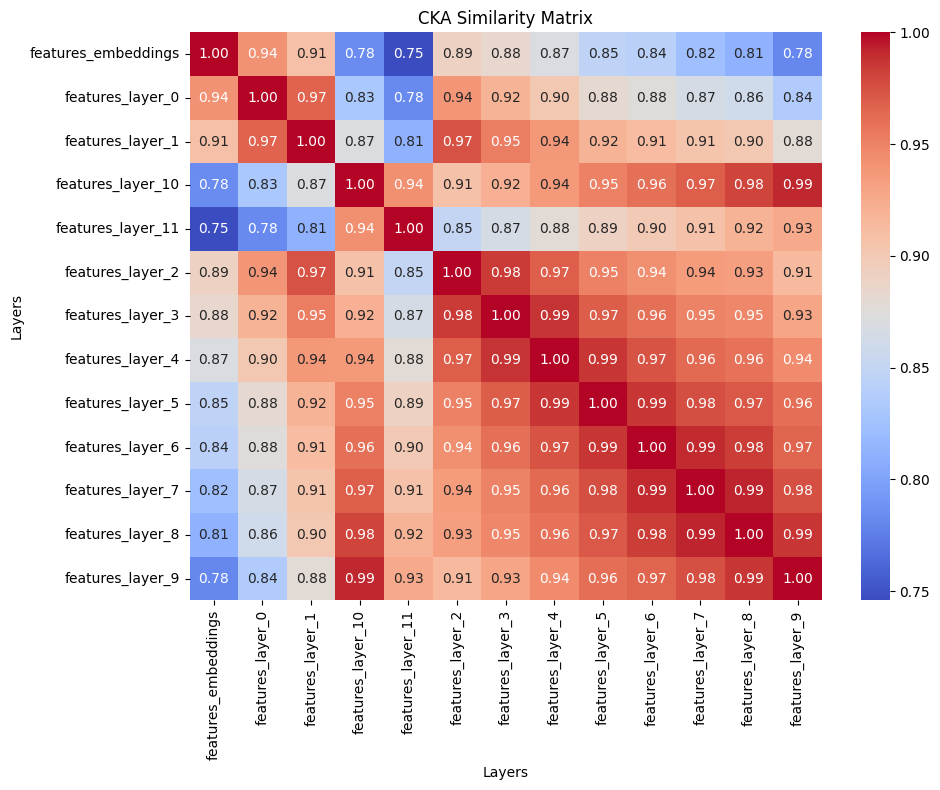

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def _center(X):
    """Center the matrix by subtracting the mean of each column."""
    return X - X.mean(axis=0, keepdims=True)

def linear_cka(X, Y, eps=1e-12):
    """
    Compute the linear CKA (Centered Kernel Alignment) similarity between two matrices X and Y.

    Args:
        X (np.ndarray): First matrix of shape (n_samples, n_features).
        Y (np.ndarray): Second matrix of shape (n_samples, n_features).
        eps (float, optional): Small value to avoid division by zero. Defaults to 1e-12.

    Returns:
        float: CKA similarity value between X and Y.
    """
    X = _center(X)
    Y = _center(Y)
    XtY = X.T @ Y
    num = np.linalg.norm(XtY, ord="fro")**2
    den = (np.linalg.norm(X.T @ X, ord="fro") * np.linalg.norm(Y.T @ Y, ord="fro")) + eps
    return float(num / den)

def cka_matrix(layers):
    """
    Compute the CKA similarity matrix for a list of layers.

    Args:
        layers (list of np.ndarray): List of matrices representing layers.

    Returns:
        np.ndarray: Symmetric matrix of CKA similarity values.
    """
    L = len(layers)
    M = np.eye(L, dtype=float)
    for i in range(L):
        for j in range(i + 1, L):
            v = linear_cka(layers[i], layers[j])
            M[i, j] = M[j, i] = v
    return M

def plot_cka_matrix(cka_matrix, layer_names, figsize=(10, 8)):
    """
    Plot the CKA similarity matrix as a heatmap.

    Args:
        cka_matrix (np.ndarray): Symmetric matrix of CKA similarity values.
        layer_names (list of str): Names of the layers corresponding to the matrix.
        figsize (tuple, optional): Size of the heatmap figure. Defaults to (10, 8).
    """
    plt.figure(figsize=figsize)
    sns.heatmap(cka_matrix, xticklabels=layer_names, yticklabels=layer_names, cmap="coolwarm", annot=True, fmt=".2f")
    plt.title("CKA Similarity Matrix")
    plt.xlabel("Layers")
    plt.ylabel("Layers")
    plt.tight_layout()
    plt.show()

#Example usage
# Assuming `full_dataset` is a dictionary with layer names as keys and their corresponding matrices as values
loaded_data = np.load('../data/features/full_rte_allsplits_features.npz', allow_pickle=True)
feature_keys = [k for k in loaded_data.files if k.startswith("features_")]
full_dataset = {k: loaded_data[k][:2490] for k in feature_keys}
layers = [full_dataset[k] for k in sorted(feature_keys)]
layer_names = sorted(feature_keys)
layer_names = ["features_input" if n == "features_embeddings" else n for n in layer_names]
cka_mat = cka_matrix(layers)
plot_cka_matrix(cka_mat, layer_names)

In [11]:
def sort_layers(layers):
    """
    Sort layers in the order: embeddings, layer_0, layer_1, ..., layer_11.

    Args:
        layers (list of str): List of layer names.

    Returns:
        list of str: Sorted list of layer names.
    """
    def layer_key(x):
        if x == "features_embeddings":
            return -1  # embeddings should come first
        if x.startswith("features_layer_"):
            try:
                return int(x.split("_")[-1])  # extract the layer number
            except ValueError:
                pass
        return float('inf')  # put unknown layers at the end

    return ["features_input" if n == "features_embeddings" else n for n in sorted(layers, key=layer_key)]

# Update the plot_feature_boxplot_by_layer_from_npz_v3 function to use the new sorting function
def plot_feature_boxplot_by_layer_from_npz_v4(npz_file_path, sort_layers=True, showfliers=False, figsize=(12, 6)):
    """
    Plot boxplots of all features' distributions across layers from an NPZ file.

    Args:
        npz_file_path (str): Path to the NPZ file containing features.
        sort_layers (bool, optional): Whether to sort layers in ascending order. Defaults to True.
        showfliers (bool, optional): Whether to show outliers in the boxplot. Defaults to False.
        figsize (tuple, optional): Figure size. Defaults to (12, 6).
    """
    # Load the NPZ file
    loaded_data = np.load(npz_file_path, allow_pickle=True)

    print("Available arrays in the file:", loaded_data.files)

    # Extract feature keys and labels
    feature_keys = [k for k in loaded_data.files if k.startswith("features_")]
    full_dataset = {k: loaded_data[k][:2490] for k in feature_keys}

    # Convert the dataset into a DataFrame
    data = []
    for layer, values in full_dataset.items():
        for instance_values in values:
            data.append({"layer": layer, "value": instance_values})

    meta_df = pd.DataFrame(data)

    # Ensure "value" is list-like for explode
    def to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, list):
            return v
        # scalar -> list with one element (so explode still works)
        return [v]

    meta_df["value"] = meta_df["value"].apply(to_list)
    meta_df = meta_df.explode("value", ignore_index=True)

    # Convert to numeric, drop bad rows
    meta_df["value"] = pd.to_numeric(meta_df["value"], errors="coerce")
    meta_df = meta_df.dropna(subset=["value"])

    # Sort layers in the desired order
    layers = meta_df["layer"].unique().tolist()
    if sort_layers:
        layers = sort_layers(layers)

    data = [meta_df.loc[meta_df["layer"] == L, "value"].values for L in layers]

    plt.figure(figsize=figsize)
    plt.boxplot(data, labels=layers, showfliers=showfliers)
    plt.title("Feature Distributions by Layer")
    plt.xlabel("Layer")
    plt.ylabel("Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Example usage
plot_feature_boxplot_by_layer_from_npz_v4(
    npz_file_path="../data/features/full_rte_allsplits_features.npz"
)

Available arrays in the file: ['features_embeddings', 'features_layer_0', 'features_layer_1', 'features_layer_2', 'features_layer_3', 'features_layer_4', 'features_layer_5', 'features_layer_6', 'features_layer_7', 'features_layer_8', 'features_layer_9', 'features_layer_10', 'features_layer_11', 'labels']


TypeError: 'bool' object is not callable

In [ ]:
def plot_cka_matrix_v2(cka_matrix, layer_names, figsize=(10, 8)):
    """
    Plot the CKA similarity matrix as a heatmap with layers sorted in the desired order.

    Args:
        cka_matrix (np.ndarray): Symmetric matrix of CKA similarity values.
        layer_names (list of str): Names of the layers corresponding to the matrix.
        figsize (tuple, optional): Size of the heatmap figure. Defaults to (10, 8).
    """
    # Sort layers in the desired order
    def layer_key(x):
        if x == "features_embeddings":
            return -1  # embeddings should come first
        if x.startswith("features_layer_"):
            try:
                return int(x.split("_")[-1])  # extract the layer number
            except ValueError:
                pass
        return float('inf')  # put unknown layers at the end

    sorted_indices = sorted(range(len(layer_names)), key=lambda i: layer_key(layer_names[i]))
    sorted_layer_names = [layer_names[i] for i in sorted_indices]
    sorted_layer_names = ["features_input" if n == "features_embeddings" else n for n in sorted_layer_names]
    sorted_cka_matrix = cka_matrix[np.ix_(sorted_indices, sorted_indices)]

    # Plot the heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(sorted_cka_matrix, xticklabels=sorted_layer_names, yticklabels=sorted_layer_names, cmap="coolwarm", annot=True, fmt=".2f")
    plt.title("CKA Similarity Matrix (Sorted)")
    plt.xlabel("Layers")
    plt.ylabel("Layers")
    plt.tight_layout()
    plt.show()

# Example usage
# Assuming `cka_mat` is the CKA matrix and `layer_names` is the list of layer names
# plot_cka_matrix_v2(cka_mat, layer_names)